# Sewage on the Dart: How Bad Is It Really, and How Does It Compare?

*BEE2041 Empirical Project*

---

<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain the general logic i.e. paddle the dart>want to know whether the water is full of sewage>how bad is the problem>relative to other rivers and other water companies across the country for a better understanding
-->

---

---

### Section 0 - Setup

The cell below imports all libraries used in this notebook and sets some plot styles and output formatting.

In [211]:
import os # for interacting with the computer's file system e.g. to create folders or file paths for the correct OS (i.e. fixes / vs \ between mac/linux and windows)
import time # allows us to use things like time.sleep() later
import warnings # allows us to do things like suppressing warning messages (done later in this code block)
import zipfile # allows us to read and extract ZIP  files

import numpy as np # for numerical operations
import pandas as pd # necessary for data manipulation - dataframes used later are from this

import requests #  lets Python make HTTP requests (allows us to download data and query APIs later)

import matplotlib.pyplot as plt # library for python plotting
import matplotlib.ticker as mticker # allows for control of axis formatting
import seaborn as sns # a better python plotting library atop matplot (better looking plots ect.)
import folium # library for creating interacive maps (to use later to map sewage overflow locations)

import statsmodels.formula.api as smf  # for OLS regression at Scales 1, 2, and 3

from IPython.display import display # allows outputs (specifically dataframes) to be nicely formatted in outputs

warnings.filterwarnings('ignore') # suppresses some warning messages for minor problems (avoids messy outputs from unnecessary error messages)

sns.set_theme(style='whitegrid', font_scale=1.1) # sets global seaborn plot styling 
COLOUR_DART = '#1f6aa5'   # blue — used for Dart-specific highlights
COLOUR_SWW = '#e07b39'   # orange — used for other SWW rivers
COLOUR_NATIONAL = '#6c757d'   # grey — national/other companies

OUTPUTS_DIR = os.path.join('outputs')  # directory for saving chart output files
os.makedirs(OUTPUTS_DIR, exist_ok=True)  # creates the folder if it does not already exist

print('Setup complete.')

Setup complete.


## Phase 1 - Data Collection

> this phase downloads all data sources and fetches all rainfall figures from the EA Hydrology API
> no analysis runs here - all outputs saved to data/raw/ or data/processed/
> note: SWW catchment gauge fetch (section 3b) appears after catchment identification in Section 2 - this ordering is intentional

#### Helper Functions - compute_storm_days() and get_wfd_catchment_col()

> what compute_storm_days() does: takes a daily rainfall dataframe and returns annual storm_days counts per year
> arguments: daily_df (dataframe with 'year' and rain_col columns), rain_col (default 'rainfall_mm'), thresholds (default (10, 15, 20))
> averaging approach: for multi-gauge inputs (ie the manually selected dart inputs), averages daily readings across gauges per date first, then applies threshold to the averaged figure - do NOT compute storm days per gauge then average counts
> called in: Section 3b (dart) and Section 3c (SWW catchments)

> what get_wfd_catchment_col() does: returns the correct WFD catchment column name for a given year
> returns the column name string for that years WFD catchment column
> called in: unique catchment names inspection cell, dart variants inspection cell, DART vs Dart investigation cell, Section 2b

In [212]:
def compute_storm_days(daily_df, rain_col='rainfall_mm', thresholds=(10, 15, 20)):
    # ensures a day only counts as a storm day if the catchment average exceeded the threshold
    daily_avg = (daily_df.groupby(['date', 'year'])[rain_col].mean().reset_index())  # averages across gauges for each day

    records = []  # empty list to fill with one dictionary per year
    for year, group in daily_avg.groupby('year'):  # loops through each years daily data
        row = {'year': year}  # starts each years dictionary with just the year
        for t in thresholds:  # loops through each threshold
            row[f'storm_days_{t}'] = (group[rain_col] >= t).sum()  # sums the number of days where averaged rainfall met or exceeded the threshold
        records.append(row)  # adds the years dictionary to the records list

    return pd.DataFrame(records).sort_values('year').reset_index(drop=True)  # converts list of dictionaries to dataframe, sorted by year

In [213]:
def get_wfd_catchment_col(year):
    # returns the correct WFD catchment column name for a given year - 2021-2023 use cycle 2 naming, 2024 uses cycle 3 naming (confirmed in 2a inspection cells)
    if year == 2024:
        return 'WFD Waterbody Catchment Name (Cycle 3)\n(discharge outlet)'
    else:
        return 'WFD Waterbody Catchment Name (Cycle 2)\n(discharge outlet)'

### Section 1a - Fetch EDM Storm Overflow Data
Scales 1, 2, and 3 - downloads the raw EDM Excel files for all four years. These files contain overflow data for every water company in England, so they feed all three scales.
> here: explain what the cell does - requests the excel files of this publicly published data for each year>saves them to a raw data file locally>ensures files aren't re-downloaded when running the code again.
> here: explain the logic of this method - rather than manually downloading the files>retreive them programmatically (even if more faffy at the time)>avoids manual steps>ensures better reproducibility.
> here: explain 2020 being dropped - 2020 has separate per-company Excel files rather than combined file>inconsistent with other years>overcomplicates what would be required>dropped for ease (is oldest data anyway)>allows for pipeline to be clearer and built quicker>also explain finding: EDM files are zips containing a subfolder, inside which are several files includinh two excel files (a combined all-companies file and a summary file).

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain what the EDM dataset is - the environment agency requires water companies to fit discharge monitors on storm overflows.
reference the dataset somewhere properly to avoid copyright ect.
-->
---

In [214]:
# creates dictionary mapping year to the URL where the zip folder holds that year's data
EDM_URLS = {
    2021: 'https://environment.data.gov.uk/api/file/download?fileDataSetId=c55e170e-3c75-49a5-8026-a961ff94c8e0&fileName=EDM_2021_Storm_Overflow_Annual_Return.zip',
    2022: 'https://environment.data.gov.uk/api/file/download?fileDataSetId=c55e170e-3c75-49a5-8026-a961ff94c8e0&fileName=EDM_2022_Storm_Overflow_Annual_Return.zip',
    2023: 'https://environment.data.gov.uk/api/file/download?fileDataSetId=c55e170e-3c75-49a5-8026-a961ff94c8e0&fileName=EDM_2023_Storm_Overflow_Annual_Return.zip',
    2024: 'https://environment.data.gov.uk/api/file/download?fileDataSetId=c55e170e-3c75-49a5-8026-a961ff94c8e0&fileName=EDM_2024_Storm_Overflow_Annual_Return.zip',}

RAW_DIR = os.path.join('data', 'raw') # builds the path (with correct slash directions) to data/raw/ where extracted Excel files will be saved.
os.makedirs(RAW_DIR, exist_ok=True) # creates the directory/folder (if it doesnt already exist)

def download_and_extract_edm(year, url, raw_dir): # defines a function which takes 3 inputs (year, url, and raw directory)
    
    # defines clean output filenames for the two Excel files we extract from each ZIP.
    main_filename = f'edm_main_{year}.xlsx' # edm_main_YYYY.xlsx = all companies combined
    summary_filename = f'edm_summary_{year}.xlsx' # edm_summary_YYYY.xlsx = national company-level totals (for national comparison later)
    # sets the file paths for each of the files extracted from each zip
    main_filepath = os.path.join(raw_dir, main_filename)
    summary_filepath = os.path.join(raw_dir, summary_filename)

    # skips the download if both files already exist locally - then lets the user know this has happened and the locations of each file
    if os.path.exists(main_filepath) and os.path.exists(summary_filepath):
        print(f'  {year}: already exists, skipping download.')
        return main_filepath, summary_filepath

    print(f'  {year}: downloading...', flush=True) # flush=True forces python to print the text immediately so that whats happening in real time can be seen
    response = requests.get(url, timeout=60) # sends an HTTP get request to the URL, saving the response. allows 1 minute wait for a response
    response.raise_for_status() # stops and gives a clear error if the server returned a failure code e.g. a 404 error


    zip_filepath = os.path.join(raw_dir, f'edm_{year}_temp.zip') # creates filepath for the temporary zip file the same as we've done before
    # saves the zip file to disk (temporarily) so zipfile can open it
    with open(zip_filepath, 'wb') as f:
        f.write(response.content) # writes the downloaded data to the disk (in binary mode)


    with zipfile.ZipFile(zip_filepath) as zf:
        all_files = zf.namelist() # returns all file paths inside the zip

        for file_path in all_files: # loops through each of the file paths within the zip
            # split('/') will split the string at every / (i.e. between levels within the filepath), meaning the final ([-1]) string after this spit is simply the filename
            # .lower() makes the matching case-insensitive.
            filename_only = file_path.split('/')[-1].lower()

            # identifies the main all-companies excel file and saves it.
            if 'all water and sewerage' in filename_only and filename_only.endswith('.xlsx'):
                with zf.open(file_path) as source, open(main_filepath, 'wb') as target:
                    target.write(source.read()) # copy contents from zip to disk (in binary mode)

            # identifies the summary excel file and saves it.
            elif 'summary data' in filename_only and filename_only.endswith('.xlsx'):
                with zf.open(file_path) as source, open(summary_filepath, 'wb') as target:
                    target.write(source.read()) # copy contents from zip to disk (in binary mode)
                    
    os.remove(zip_filepath) # deletes the temporary zip file now that everythings extracted (keeps our folder clean)
    
    # verifies both files were successfully extracted - raises errors if they weren't
    if not os.path.exists(main_filepath):
        raise FileNotFoundError(f'Could not find main all-companies Excel file in ZIP for {year}')
    if not os.path.exists(summary_filepath):
        raise FileNotFoundError(f'Could not find summary Excel file in ZIP for {year}')

    print('done.')
    time.sleep(0.5) # brief pause between server requests for politeness
    return main_filepath, summary_filepath

print('Downloading and extracting EDM files...')
# creates two empty dictionaries before the loop starts
edm_main_paths = {}
edm_summary_paths = {}

for year, url in EDM_URLS.items():
    main_path, summary_path = download_and_extract_edm(year, url, RAW_DIR) # calls the above function - saving the two file paths it returns
    # adds an entry to each dictionary for the current year
    edm_main_paths[year] = main_path
    edm_summary_paths[year] = summary_path

# prints a confirmation of what was downloaded - to visually verify everything worked
print('\nAll EDM files ready.')
print('\nMain files:')
for year, path in edm_main_paths.items(): 
    print(f'  {year}: {path}')
print('\nSummary files:')
for year, path in edm_summary_paths.items():
    print(f'  {year}: {path}')

  2021: already exists, skipping download.
  2022: already exists, skipping download.
  2023: already exists, skipping download.
  2024: already exists, skipping download.

All EDM files ready.

Main files:
  2021: data\raw\edm_main_2021.xlsx
  2022: data\raw\edm_main_2022.xlsx
  2023: data\raw\edm_main_2023.xlsx
  2024: data\raw\edm_main_2024.xlsx

Summary files:
  2021: data\raw\edm_summary_2021.xlsx
  2022: data\raw\edm_summary_2022.xlsx
  2023: data\raw\edm_summary_2023.xlsx
  2024: data\raw\edm_summary_2024.xlsx


### 1a inspection cells - EDM
Scales 1, 2, and 3 — exploratory cells understanding the EDM file structure. Feeds the logic for parsing used at all scales.
> inspection cell - inspects sheet names, header structure, and column layout of edm_main_YYYY.xlsx files
> here: explain that this section is purely throwaway cells (temporary to verify logic and understand the data>can build proper logic later based upon this understanding
> here: explain what the cells do (check what sheets exist, what the columns look like and filter for the desired recieving water naming) and clarify it is not essential to the logic pipeline.
> answers these: what are the sheet names? - i know there's a SWW sheet but not (without manual inspection) exactly what it's called. where do the column headers actually start? - may have rows of metadata ect. at the top (before the real data starts) what are the column names? - i need the exact column names to know which have spill counts, spill durations, location names etc. what are the names we need from recieving water variable?

In [215]:
for year, path in edm_main_paths.items(): # cycles through each of the excel files
    xl = pd.ExcelFile(path) # accesses the current excel file's structure (without loading any data)
    print(f'\n{year} sheets:')
    for sheet in xl.sheet_names: # gives us a list of every sheet in the excel file
        print(f'  {sheet}')


2021 sheets:
  Anglian Water 2021
  DCWW 2021
  Northumbrian Water 2021
  Severn Trent 2021
  South West Water 2021
  Southern Water 2021
  Thames Water 2021
  United Utilities 2021
  Wessex Water 2021
  Yorkshire Water 2021

2022 sheets:
  Anglian Water 2022
  DCWW 2022
  Northumbrian Water 2022
  Severn Trent 2022
  South West Water 2022
  Southern Water 2022
  Thames Water 2022
  United Utilities 2022
  Wessex Water 2022
  Yorkshire Water 2022

2023 sheets:
  Anglian Water 2023
  DCWW 2023
  Northumbrian Water 2023
  Severn Trent 2023
  South West Water 2023
  Southern Water 2023
  Thames Water 2023
  United Utilities 2023
  Wessex Water 2023
  Yorkshire Water 2023

2024 sheets:
  Anglian Water 2024
  DCWW 2024
  Northumbrian Water 2024
  Severn Trent 2024
  South West Water 2024
  Southern Water 2024
  Thames Water 2024
  United Utilities 2024
  Wessex Water 2024
  Yorkshire Water 2024


In [216]:
# previews the structure of SWW sheets - including any any header rows atop the file
for year, path in edm_main_paths.items():  # cycles through each of the excel files
    print(f'\n{year} — first 5 rows:')
    preview = pd.read_excel(path, sheet_name=f'South West Water {year}', header=None, nrows=5) # limits reading to the first 5 rows (i just want an understanding of the sheet's layout not to see the whole sheet)
    display(preview)


2021 — first 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,EDM STORM OVERFLOW REGULATORY ANNUAL RETURN - ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Water Company Name,Site Name\n(EA Consents Database),Site Name\n(WaSC operational)\n[optional],EA Permit Reference\n(EA Consents Database),WaSC Supplementary Permit Ref.\n[optional],Activity Reference on Permit\n(if >1 discharge...,Storm Discharge Asset Type,Outlet Discharge NGR\n(EA Consents Database),WFD Waterbody ID (Cycle 2)\n(discharge outlet),WFD Waterbody Catchment Name (Cycle 2)\n(disch...,...,Bathing Water\n(only populate for storm overfl...,Initial EDM Commission Date,Total Duration (hrs) all spills prior to proce...,Counted spills using 12-24h count method,EDM Operation -\n% of reporting period EDM ope...,EDM Operation -\nReporting % -\nPrimary Reason...,EDM Operation -\nAction taken / planned -\nSta...,High Spill Frequency -\nOperational Review -\n...,High Spill Frequency -\nAction taken / planned...,High Spill Frequency -\nEnvironmental Enhancem...
2,South West Water,11 HIGH STREET CSO,11 HIGH STREET_CSO_HATHERLEIGH,201777,201777,A1,SO on sewer network,SS 5405 0422,GB108050008220,Lower River Lew (Torridge),...,NaN,Commissioned pre-2016 - full year data expected,0,0,100,NaN,NaN,NaN,NaN,NaN
3,South West Water,DUNNING WALK COMBINED SEWER OVERFLO,XX DUNNINGS WALK_CSO_TEIGNMOUTH,201684,201684,A1,SO on sewer network,SX 9315 7402,22,NaN,...,NaN,Commissioned in 2018 - full year data expected,0.83,5,97,NaN,NaN,NaN,NaN,NaN
4,South West Water,121A ST. KATHERINES ROAD CSO,121a ST KATHERINES RD_CSO_EXETER,201904,201904,A1,SO on sewer network,SX 9419 9387,GB108045009050,North Brook (East Devon),...,NaN,Commissioned in 2017 - full year data expected,33.31,14,100,NaN,NaN,NaN,NaN,NaN



2022 — first 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,EDM STORM OVERFLOW REGULATORY ANNUAL RETURN 2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Complete columns U & V when data in column T i...,NaN,"Enter in columns W, X, Y when relevant spill f...",NaN,NaN
1,Water Company Name,Site Name\n(EA Consents Database),Site Name\n(WaSC operational)\n[optional],EA Permit Reference\n(EA Consents Database),WaSC Supplementary Permit Ref.\n[optional],Activity Reference on Permit,Storm Discharge Asset Type,Outlet Discharge NGR\n(EA Consents Database),WFD Waterbody ID (Cycle 2)\n(discharge outlet),WFD Waterbody Catchment Name (Cycle 2)\n(disch...,...,Total Duration (hrs) all spills prior to proce...,Counted spills using 12-24h count method,Long-term average spill count,No. full years EDM data\n(years),EDM Operation -\n% of reporting period EDM ope...,EDM Operation -\nReporting % -\nPrimary Reason...,EDM Operation -\nAction taken / planned -\nSta...,High Spill Frequency -\nOperational Review -\n...,High Spill Frequency -\nAction taken / planned...,High Spill Frequency -\nEnvironmental Enhancem...
2,South West Water,"SEA LAWNS OUTFALL CSO, DAWLISH",SEA LAWNS SPS_PSCSOEO_DAWLISH,200828,200828,A1,Storm discharge at pumping station,SX9674077100,GB650806420000,Lyme Bay West,...,25.93,18,25.25,4 (installed 2018),100,NaN,NaN,NaN,NaN,NaN
3,South West Water,11 HIGH STREET CSO,11 HIGH STREET_CSO_HATHERLEIGH,201777,201777,A1,SO on sewer network,SS 5405 0422,GB108050008220,Lower River Lew (Torridge),...,2.3,12,2.5,6 (installed 2016),99,NaN,NaN,NaN,NaN,NaN
4,South West Water,DUNNING WALK COMBINED SEWER OVERFLO,XX DUNNINGS WALK_CSO_TEIGNMOUTH,201684,201684,A1,SO on sewer network,SX 9315 7402,22,NaN,...,0.53,5,4.25,4 (installed 2018),42,Comms failure / issue,Resolved - May,NaN,NaN,NaN



2023 — first 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,EDM STORM OVERFLOW REGULATORY ANNUAL RETURN 2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Complete columns U & V when data in column T i...,NaN,"Enter in columns W, X, Y when relevant spill f...",NaN,NaN,NaN
1,Water Company Name,Site Name\n(EA Consents Database),Site Name\n(WaSC operational)\n[optional],EA Permit Reference\n(EA Consents Database),WaSC Supplementary Permit Ref.\n[optional],Activity Reference on Permit,Storm Discharge Asset Type,Outlet Discharge NGR\n(EA Consents Database),WFD Waterbody ID (Cycle 2)\n(discharge outlet),WFD Waterbody Catchment Name (Cycle 2)\n(disch...,...,Counted spills using 12-24h count method,Long-term average spill count,No. full years EDM data\n(years),EDM Operation -\n% of reporting period EDM ope...,EDM Operation -\nReporting % -\nPrimary Reason...,EDM Operation -\nAction taken / planned -\nSta...,High Spill Frequency -\nOperational Review -\n...,High Spill Frequency -\nAction taken / planned...,High Spill Frequency -\nEnvironmental Enhancem...,Unique ID
2,South West Water,11 HIGH STREET CSO,11 HIGH STREET_CSO_HATHERLEIGH,201777,201777,A1,SO on sewer network,SS 5405 0422,GB108050008220,Lower River Lew (Torridge),...,47,8.857143,7 (installed 2016),100,NaN,NaN,NaN,NaN,NaN,SWW0001
3,South West Water,DUNNING WALK COMBINED SEWER OVERFLO,XX DUNNINGS WALK_CSO_TEIGNMOUTH,201684,201684,A1,SO on sewer network,SX 9315 7402,22,NaN,...,6,4.6,5 (installed 2018),68.931507,Comms failure / issue,Resolved - Sep,NaN,NaN,NaN,SWW0002
4,South West Water,121A ST. KATHERINES ROAD CSO,121a ST KATHERINES RD_CSO_EXETER,201904,201904,A1,SO on sewer network,SX 9419 9387,GB108045009050,North Brook (East Devon),...,16,9.833333,6 (installed 2017),100,NaN,NaN,NaN,NaN,NaN,SWW0003



2024 — first 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,EDM STORM OVERFLOW REGULATORY ANNUAL RETURN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Complete columns U & V when data in column T i...,NaN,Enter in columns W & X when relevant spill fre...,NaN,Columns Y & Z provide information on any inves...,NaN,Column AA provides information on SOAF investi...,NaN
1,Unique ID,Water Company Name,Site Name\n(EA Consents Database),Site Name\n(WaSC operational)\n[optional],EA Permit Reference\n(EA Consents Database),WaSC Supplementary Permit Ref.\n[optional],Activity Reference on Permit,Storm Discharge Asset Type,Outlet Discharge NGR\n(EA Consents Database),WFD Waterbody ID (Cycle 3)\n(discharge outlet),...,Data start - calendar year,EDM Operation -\n% of reporting period EDM ope...,EDM Operation -\nReporting % -\nPrimary Reason...,EDM Operation -\nAction taken / planned -\nSta...,High Spill Frequency -\nOperational Review -\n...,High Spill Frequency -\nOperational Review -\n...,Investigation activity for the reporting period,Improvement activity for the reporting period,UWWTR (SOAF) investigation status,Old format Unique ID - pre-2024 Annual Return
2,SBB00001,South West Water,NaN,CHICHESTER SCREENS_CSO_NEWTON ABBOT,Permit applied for,NaN,NaN,SO on sewer network,SX8737571545,GB510804605800,...,2021,100,NaN,NaN,High spill threshold not met,High spill threshold not met,No investigation activity in reporting period,No improvement action in reporting period,No SOAF investigation required,SWW0235
3,SBB00004,South West Water,1 EDNA TERRACE CSO,S/O ENTRY 1 EDNA TERRACE_CSO_PLYMOUTH,301737,301737,A1,SO on sewer network,SX50155478,73,...,2017,91.095932,NaN,NaN,High spill threshold not met,High spill threshold not met,No investigation activity in reporting period,No improvement action in reporting period,No SOAF investigation required,SWW1011
4,SBB00005,South West Water,11 HIGH STREET CSO,11 HIGH STREET_CSO_HATHERLEIGH,201777,201777,A1,SO on sewer network,SS54050422,GB108050008220,...,2016,100,NaN,NaN,High spill threshold not met,High spill threshold not met,No investigation activity in reporting period,No improvement action in reporting period,No SOAF investigation required,SWW0001


> finding: sheet names follow pattern 'South West Water {year}' consistently across all years
> finding: header row is consistently row 1 across all years (can use header=1 in all pd.read_excel calls)
> finding: number of columns changes across years (select columns by name not position)

In [217]:
# provides the full list of column names for each year (to allow for manual identification of the useful columns and any naming differences across years)
for year, path in edm_main_paths.items():
    df_cols = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1, nrows=0) # nrows=0 ensures just the column headers are read
    print(f'\n{year} columns:')
    for i, col in enumerate(df_cols.columns): # enumerate gives both the column position number and the column name at once
        print(f'  {i}: {col}')


2021 columns:
  0: Water Company Name
  1: Site Name
(EA Consents Database)
  2: Site Name
(WaSC operational)
[optional]
  3: EA Permit Reference
(EA Consents Database)
  4: WaSC Supplementary Permit Ref.
[optional]
  5: Activity Reference on Permit
(if >1 discharge on permit)
  6: Storm Discharge Asset Type
  7: Outlet Discharge NGR
(EA Consents Database)
  8: WFD Waterbody ID (Cycle 2)
(discharge outlet)
  9: WFD Waterbody Catchment Name (Cycle 2)
(discharge outlet)
  10: Receiving Water / Environment (common name)
(EA Consents Database)
  11: Shellfish Water
 (only populate for storm overflow with a Shellfish Water EDM requirement)
  12: Bathing Water
(only populate for storm overflow with a Bathing Water EDM requirement)
  13: Initial EDM Commission Date
  14: Total Duration (hrs) all spills prior to processing through 12-24h count method
  15: Counted spills using 12-24h count method
  16: EDM Operation -
% of reporting period EDM operational
  17: EDM Operation -
Reporting % -
P

> *key columns confirmed across years:*
> * site name: 'Site Name
(EA Consents Database)'*
> * receiving water: 'Receiving Water / Environment (common name)
(EA Consents Database)'*
> * spill count: 'Counted spills using 12-24h count method' 
> * spill duration: 'otal Duration (hrs) all spills prior to processing through 12-24h count method' in 2021-23 but changes to 'Total Duration (hh:mm:ss)...' in 24 (needs converting to decimal hours to match*
> * grid reference: 'Outlet Discharge NGR\n(EA Consents Database)' (needed for any mapping)*

In [218]:
dart_matches = [] # creates empty list to fill later

# reads all four years then filters for rows containing 'dart' in the receiving water column (case-insensitive)
for year, path in edm_main_paths.items():
    df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1)
    # .str.contains searches for a string within each string in the column
    # case=False makes the search case-insensitive
    # na=False means rows with missing values in this column return False rather than crashing
    mask = df['Receiving Water / Environment (common name)\n(EA Consents Database)'].str.contains('dart', case=False, na=False)
    dart_matches.append(df[mask]) # adds each match to the end of the dart_matches list created before

dart_matches_df = pd.concat(dart_matches, ignore_index=True) # temporarily puts all years together to see the matched river names
# prints the matches
print('Unique receiving water names matched by dart filter:')
matched_names = sorted(dart_matches_df['Receiving Water / Environment (common name)\n(EA Consents Database)'].dropna().unique())
for name in matched_names:
    print(f'  {name}')
print(f'\nTotal rows matched: {len(dart_matches_df)}')

Unique receiving water names matched by dart filter:
  DART ESTUARY
  DART ESTUARY (TIDAL)
  DART ESTUARY(E)
  DART RIVER ESTUARY(E)
  LITTLE DART RIVER
  LITTLE DART RIVER (S)
  RIVER DART
  RIVER DART (ESTUARINE)
  RIVER DART ESTUARY
  RIVER DART ESTUARY (E)
  RIVER DART ESTUARY VIA SWS
  RIVER DART ESTUARY(E)
  RIVER DART VIA SWS (ESTUARINE)
  Stream joining Lower Little Dart River
  TRIB LITTLE DART (S)
  TRIB LITTLE DART RIVER (S)
  TRIB OF R.DART(E) VIA SW SEWER
  TRIB OF THE DART ESTUARY
  TRIB. OF LITTLE DART RIVER

Total rows matched: 113


> finding: 'dart' filter also incorrectly captures little dart entries (a separate river unrelated to the river dart we are analysing) and estuarine entries (sites discharging into the tidal Dart Estuary rather than the freshwater river)
fix: add second filter excluding any row containing 'little dart' and 'estuar'

In [219]:
# removes little dart entries from matched results (the little dart is a separate river unrelated to the river dart we are analysing)

receiving_water_col = 'Receiving Water / Environment (common name)\n(EA Consents Database)'
is_not_little_dart = ~dart_matches_df[receiving_water_col].str.contains('little dart', case=False, na=False)
dart_all = dart_matches_df[is_not_little_dart].copy()

# prints the final matches after little dart removal
print(f'Rows after removing Little Dart entries: {len(dart_all)}')
print(f'\nConfirmed Dart catchment receiving water names:')
for name in sorted(dart_all[receiving_water_col].dropna().unique()):
    print(f'  {name}')

Rows after removing Little Dart entries: 88

Confirmed Dart catchment receiving water names:
  DART ESTUARY
  DART ESTUARY (TIDAL)
  DART ESTUARY(E)
  DART RIVER ESTUARY(E)
  RIVER DART
  RIVER DART (ESTUARINE)
  RIVER DART ESTUARY
  RIVER DART ESTUARY (E)
  RIVER DART ESTUARY VIA SWS
  RIVER DART ESTUARY(E)
  RIVER DART VIA SWS (ESTUARINE)
  TRIB OF R.DART(E) VIA SW SEWER
  TRIB OF THE DART ESTUARY


### Section 1b - Fetch Met Office Regional Rainfall Files
Scale 3 only - fetches the met office regional rainfall text files. These are used exclusively for the national water company OLS at scale 3.
> here: explain what the met office UK regional series is - regional precipitation series>monthly totals going back decades>plain text files fetched directly from the met office
> here: explain the regions fetched and why - each maps to one or more water companies used in the national comparison at scale 3>six files covering the finest available met office sub-regions for each companys operating area
> here: explain the save to disk approach>files saved to data/raw/ as .txt files>os.path.exists() prevents re-fetching on further runs
> note: series provides monthly totals only - daily data is not available>this means storm_days_10 cannot be computed at scale 3>annual_rainfall_mm (the 'ann' column) used as the OLS regressor instead>inconsistency with scales 1 and 2 acknowledged - discussed in scale 3 analysis

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain what the regional series is and why we need it - want to compare water companies nationally>companies operate in different regions with different climates>need a rainfall baseline per region to make the comparison fair>we use the most granular region available for each company to ensure the rainfall figure is as representative as possible
-->
---

In [220]:
# maps each regions lowercase filename key to its exact met office filename
# multiple companies may share a region (e.g. SWW and wessex both in England_SW_and_S_Wales)
MET_REGIONS = {
    'england_sw_and_s_wales':   'England_SW_and_S_Wales',    # south west water, wessex water
    'england_se_and_central_s': 'England_SE_and_Central_S',  # southern water, thames water
    'east_anglia':              'East_Anglia',                # anglian water
    'midlands':                 'Midlands',                   # severn trent water
    'england_nw_and_n_wales':   'England_NW_and_N_Wales',    # united utilities, welsh water
    'england_e_and_ne':         'England_E_and_NE',          # yorkshire water, northumbrian water
}

MET_REGIONS_BASE_URL = 'https://www.metoffice.gov.uk/pub/data/weather/uk/climate/datasets/Rainfall/date/' # base URL - region filename appended in the loop below

for region_key, region_name in MET_REGIONS.items():
    filepath = os.path.join('data', 'raw', f'met_region_{region_key}.txt') # builds the save path for this regions file
    if not os.path.exists(filepath): # skips the download if the file already exists
        url = MET_REGIONS_BASE_URL + region_name + '.txt' # constructs the full URL for this region
        response = requests.get(url, timeout=60) # sends a get request to the URL, saving the response. allows 1 minute wait for a response
        response.raise_for_status() # stops and raises an error if the server returned a failure code
        with open(filepath, 'w') as f:
            f.write(response.text) # writes the raw text response to disk
        print(f'  saved: {filepath}') # prints the filepath it was saved to
    else:
        print(f'  already exists, skipping: {filepath}') # tells the user the save was skipped and gives filepath for where it was saved

print('\nAll Met Office regional rainfall files ready.')

  already exists, skipping: data\raw\met_region_england_sw_and_s_wales.txt
  already exists, skipping: data\raw\met_region_england_se_and_central_s.txt
  already exists, skipping: data\raw\met_region_east_anglia.txt
  already exists, skipping: data\raw\met_region_midlands.txt
  already exists, skipping: data\raw\met_region_england_nw_and_n_wales.txt
  already exists, skipping: data\raw\met_region_england_e_and_ne.txt

All Met Office regional rainfall files ready.


### 1b Inspection cells - Met Office regional rainfall
Scale 3 only - confirms the file structure and the ann (annual rainfall mm) column that scale 3 OLS will use.
> inspection cell - confirms skiprows value lands correctly on the header row and that the 'ann' column is present

In [221]:
# previews the SW file to confirm the correct skiprows value and column layout
sample_path = os.path.join('data', 'raw', 'met_region_england_sw_and_s_wales.txt')
df_met_preview = pd.read_csv(sample_path, skiprows=5, sep=r'\s+') # skiprows=5 - skips the metadata block at the top of each file
print(df_met_preview.tail(10)) # tail rather than head - confirms the most recent years are present
print(f'\nColumns: {df_met_preview.columns.tolist()}')

     year    jan    feb    mar    apr    may    jun    jul    aug    sep  \
181  2017   89.2   92.4  122.4   26.1   66.9  100.8  115.3   88.3  138.8   
182  2018  153.9   65.2  168.2  103.0   49.3   13.7   52.7   91.0   89.0   
183  2019   72.1   78.0  130.2   77.3   35.2  111.6   46.7  117.4  163.6   
184  2020  128.6  240.9   91.0   44.1   12.1  135.4   77.0  153.9   59.4   
185  2021  173.6  132.8   63.8   13.4  188.4   50.1   99.4   61.3   98.3   
186  2022   60.4  140.9   63.3   36.9   57.1   69.1   29.3   35.3  111.1   
187  2023  173.0   21.0  196.5   86.9   50.0   35.8  158.0  101.6  120.7   
188  2024  125.9  227.8  159.7  115.0   94.7   35.5   94.1   73.1  160.5   
189  2025  159.8   98.6   16.9   83.6   37.8   90.2   43.5   61.2  152.2   
190  2026  215.3  173.7   67.5  588.7    NaN    NaN    NaN    NaN    NaN   

       oct    nov    dec    win    spr    sum    aut     ann  
181   77.7  106.9  160.7  239.1  215.4  304.4  323.3  1185.4  
182  104.8  180.6  173.8  379.8  320.

> finding: skiprows=5 lands correctly - columns are year, monthly totals (jan-dec), seasonal totals (win/spr/sum/aut), and ann (annual total in mm)>ann column confirmed present and will be used as annual_rainfall_mm at scale 3>filter to year <=2024 required in phase 2 analysis>structure assumed consistent across region files given they are from the same met office series - verify if parse errors arise in phase 2

### Section 2a - Parse EDM Storm Overflow Data
Scale 1 data collection - filters the EDM files to the Dart receiving water, parses spill counts and durations, produces dart_overflows.csv. Purely scale 1.
> here: explain what the cell does - reads the SWW sheet from each year's Excel file>extract the key columns>apply the freshwater dart filter (confirmed from inspection cells^) - matches 'dart' and excludes 'little dart' and any estuarine entries containing 'estuar'>deals with the difference in time format from 2024>merge all years into a single dataframe saved to the processed data filepath

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain what the EDM data shows at the Dart level - how many overflows, what sites, what years
-->
---

In [222]:
# confirmed column names (from inspection cells^)
COL_SITE = 'Site Name\n(EA Consents Database)'
COL_WATER = 'Receiving Water / Environment (common name)\n(EA Consents Database)'
COL_GRID_REF = 'Outlet Discharge NGR\n(EA Consents Database)'
COL_SPILLS = 'Counted spills using 12-24h count method'
COL_DUR_HRS = 'Total Duration (hrs) all spills prior to processing through 12-24h count method'  # 2021–2023
COL_DUR_HHMMSS = 'Total Duration (hh:mm:ss) all spills prior to processing through 12-24h count method'  # 2024 only

PROCESSED_DIR = os.path.join('data', 'processed')# builds the filepath
os.makedirs(PROCESSED_DIR, exist_ok=True) # makes the folder if it doesnt already exist

# converts the 2024 days hrs:mins:secs string to decimal hours (to match other years)
def hhmmss_to_hours(val):
    if pd.isna(val) or str(val).strip() == '':  # catches any missing or empty values before we try to split
        return np.nan  # returns NaN for blank or missing values
    
    val_str = str(val).strip()
    
    # deals with any strings put wackily by pandas to include days e.g. 1 days 13:45:00 **always put as 'days' even if only 1 day**
    days = 0
    if 'days' in val_str: # detects if string includes 'days'
        parts_days = val_str.split('days')  # splits at days ie to give '1 ', ' 13:45:00'
        days = int(parts_days[0].strip())   # extracts the number of days
        val_str = parts_days[1].strip()     # keeps just the hh:mm:ss remainder
    
    parts = val_str.split(':')  # splits the string at : (i.e. where the hrs mins and seconds are separated)
    hours   = int(parts[0])
    minutes = int(parts[1])
    seconds = int(parts[2])
    
    return (days * 24) + hours + (minutes / 60) + (seconds / 3600)  # converts to decimal hours
    
yearly_frames = []  # creates empty list (to fill with a dataframe per year)

for year, path in edm_main_paths.items(): # loops through the main excel files

    df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1)  # read the SWW sheet for this year

    # applies dart catchment filter verified in the raw inspection phase^
    is_dart = df[COL_WATER].str.contains('dart', case=False, na=False) # checks the recieving water column for 'dart' (case insensitive) and stores boolean value per row in is_dart variable
    is_little = df[COL_WATER].str.contains('little dart', case=False, na=False) # same as previous line but for 'litle dart' instead
    is_estuarine = df[COL_WATER].str.contains('estuar', case=False, na=False)  # ame as previous line but for 'estuar' instead - catches both 'estuary' and 'estuarine'
    df = df[is_dart & ~is_little & ~is_estuarine].copy() # keeps only the rows where is_dart is true and is_little and is_estuarine are not true (ie false)

    # calls the function ^ on 2024 to turn hrs, mins, seconds spill duration into decimal time value to match other years
    if year == 2024:
        df['spill_duration_hrs'] = df[COL_DUR_HHMMSS].apply(hhmmss_to_hours)
    else:
        df['spill_duration_hrs'] = pd.to_numeric(df[COL_DUR_HRS], errors='coerce') # converts excel values to clean numeric values (deals with blank or missing values by settin them as NaN)

    # renames the important columns into clean names
    df_clean = pd.DataFrame({
        'year'               : year,
        'site_name'          : df[COL_SITE].str.strip(),
        'receiving_water'    : df[COL_WATER].str.strip(),
        'grid_ref'           : df[COL_GRID_REF].str.strip(),
        'spill_count'        : pd.to_numeric(df[COL_SPILLS], errors='coerce'),
        'spill_duration_hrs' : df['spill_duration_hrs'],
    })

    yearly_frames.append(df_clean) # adds each year's cleaned dataframe to the list created before the loop
    print(f'  {year}: {len(df_clean)} Dart overflow rows parsed') # prints confirmation line for each year as it completes

dart_overflows = pd.concat(yearly_frames, ignore_index=True) # combines the dataframes in the yearly_frames list vertically into 1 (resets the indexing to not restart for each year)
print(f'\nTotal rows across all years: {len(dart_overflows)}') # prints the rowcount of the combined dataframe (sanity check that everything seems to hve worked)
display(dart_overflows.head(10)) # shows the first 10 rows of the combined dataframe (confirm visually everything seems right)

dart_overflows.to_csv(os.path.join(PROCESSED_DIR, 'dart_overflows.csv'), index=False) # saves the parsed dart overflow data to data/processed/ before any further processing
print(f'Saved: {os.path.join(PROCESSED_DIR, "dart_overflows.csv")}') # prints the filepath of the saved csv as confirmation

  2021: 5 Dart overflow rows parsed
  2022: 5 Dart overflow rows parsed
  2023: 5 Dart overflow rows parsed
  2024: 5 Dart overflow rows parsed

Total rows across all years: 20


,year,site_name,receiving_water,grid_ref,spill_count,spill_duration_hrs
0,2021,31 FORE STREET CSO,TRIB OF R.DART(E) VIA SW SEWER,SX 8057 6024,36.0,23.23
1,2021,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,112.0,773.80
2,2021,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,107.0,1340.15
3,2021,OLD WOOLLEN MILL CSO,RIVER DART,SX 7421 6715,10.0,6.77
4,2021,STAVERTON WWTW,RIVER DART,SX 7963 6363,13.0,47.33
5,2022,31 FORE STREET CSO,TRIB OF R.DART(E) VIA SW SEWER,SX 8057 6024,38.0,24.03
6,2022,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,103.0,649.65
7,2022,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,82.0,1089.16
8,2022,OLD WOOLLEN MILL CSO,RIVER DART,SX 7421 6715,7.0,48.68
9,2022,STAVERTON WWTW,RIVER DART,SX 7963 6363,7.0,57.36


Saved: data\processed\dart_overflows.csv


### 2a Inspection cells - WFD catchment names
Scale 2 data collection - despite sitting after Section 2a, these cells are all about understanding WFD catchment labels for the SWW wide analysis. They confirm the Dart vs DART distinction and the column name differences across years. scale 2 prep.
> inspection cell - confirms exact WFD catchment column name per year
> inspection cell - extracts all unique catchment names from SWW sheets across years
> inspection cell - shows catchment name values containing 'dart' across years, to see what 'dart'-labelled entries exist in the data
> inspection cell - investigates which specific sites fall under 'Dart' vs 'DART' to confirm whether they are distinct waterbodies

In [223]:
# confirms the exact name of the WFD waterbody catchment column in each year's SWW sheet
for year, path in edm_main_paths.items(): # loops through each years main excel file
    df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1, nrows=0) # reads only the header row - no data needed yet
    catchment_cols = [col for col in df.columns if 'catchment' in col.lower()] # finds any column whose name contains 'catchment' (case-insensitive)
    print(f'{year}: {catchment_cols}') # prints the matching column names for this year

2021: ['WFD Waterbody Catchment Name (Cycle 2)\n(discharge outlet)']
2022: ['WFD Waterbody Catchment Name (Cycle 2)\n(discharge outlet)']
2023: ['WFD Waterbody Catchment Name (Cycle 2)\n(discharge outlet)']
2024: ['WFD Waterbody Catchment Name (Cycle 3)\n(discharge outlet)']


In [224]:
# extracts all unique wfd catchment names from the full SWW sheet across all years
all_catchment_names = [] # creates empty list to fill with catchment names from each year

for year, path in edm_main_paths.items(): # loops through each years main excel file
    df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1) # reads the full sww sheet for this year
    catchment_col = get_wfd_catchment_col(year)  # gets the correct column name for this year (cycle 2 for 2021-2023, cycle 3 for 2024)
    names = df[catchment_col].dropna().unique().tolist() # extracts unique non null catchment names from this year
    all_catchment_names.extend(names) # adds this years names to the full list

unique_catchment_names = sorted(set(all_catchment_names)) # removes duplicates across years and sorts alphabetically
print(f'Total unique WFD catchment names: {len(unique_catchment_names)}\n')
for name in unique_catchment_names: # loops through each unique catchment name
    print(name) # prints each on a separate line for review

Total unique WFD catchment names: 264

(S) RIVER SID AND (C) LYME BAY
Abbey River
Allen
Aller Brook
Aller Brook (Teign) - Lower
Aller Brook (Teign) - Upper
Alphin Brook
Am Brook
Amble
Angarrack Stream
Ashburn
Avon (Devon Tidal) and Sth Hams - Slapton
Avon (DevonTidal) and Sth Hams - Frogmore
Avon - Lower
Avon - Upper
Aylesbeare Stream
Ayleston Brook
Benny Stream
Bidwell Brook
Blackaton Brook
Blackbrook River
Blackwater River
Bolesbridge Water
Bolingey Stream
Bradiford Water
Bradwell Stream
Branscombe Stream
Bray (Mole to Hole Water)
Bray (Source to Hole Water)
Bullow Brook
CAMEL
Caerhays Stream
Calenick Stream
Camel (De Lank to Stannon)
Canworthy Water
Carey
Carrick Roads Outer
Chelfham Stream
Claw
Combe Lake
Coney Gut
Coombe Valley Stream
Cornwall North
Corry Brook
Cotehele Stream
Crackington Stream
Crinnis River
Crooked Oak
Culvery River
DART
Dalch
Dart
Dart (Exe)
Dawlish Water
Dean Burn
Deer
Derril Water
Devon South
Dipple Water
Dolton Stream
Duntz
East Looe River
East Okemont River

> finding: the WFD waterbody catchment column is consistently named across years except 2024>2021–2023 uses 'WFD Waterbody Catchment Name (Cycle 2)' while 2024 uses 'WFD Waterbody Catchment Name (Cycle 3)'>name difference must be handled in code by selecting the correct column name per year
> finding: values are clean and already grouped at river system level>confirms the column is usable directly as a grouping variable>all-caps labels (e.g. 'DART', 'CAMEL', 'FOWEY', 'TEIGN') sit alongside title-case equivalents (possibly to represent distinct tidal/estuarine waterbodies rather than being capitalisation errors) - this is investigated in the next cell>coastal/administrative entries (e.g. 'Not part of a WFD catchment', 'Devon South', 'Cornwall North', 'Tor Bay', 'Scilly Isles') may need excluding before river level analysis

In [225]:
# shows all raw catchment name values containing 'dart' across years before any normalisation is applied
for year, path in edm_main_paths.items():  # loops through each year's main EDM excel file
    df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1)  # reads the SWW sheet for this year
    catchment_col = get_wfd_catchment_col(year)  # gets the correct column name for this year (cycle 2 for 2021-2023, cycle 3 for 2024)
    variants = df[catchment_col].dropna().unique()  # extracts all unique non-null catchment names for this year
    dart_variants = [v for v in variants if 'dart' in v.lower()]  # filters to only values containing 'dart' regardless of capitalisation
    for v in dart_variants:
        print(f'  {year}: "{v}"')  # prints each raw dart variant with its year so we can see exactly what inconsistencies exist before normalisation

  2021: "Dart (Exe)"
  2021: "Lower Little River Dart"
  2021: "Dart"
  2021: "Upper Little Dart River"
  2021: "Taw (River Yeo to Little Dart River)"
  2021: "DART"
  2022: "Dart (Exe)"
  2022: "Lower Little River Dart"
  2022: "Dart"
  2022: "DART"
  2022: "Upper Little Dart River"
  2022: "Taw (River Yeo to Little Dart River)"
  2023: "Dart (Exe)"
  2023: "Lower Little River Dart"
  2023: "Dart"
  2023: "DART"
  2023: "Upper Little Dart River"
  2023: "Taw (River Yeo to Little Dart River)"
  2024: "Dart"
  2024: "Dart (Exe)"
  2024: "Lower Little River Dart"
  2024: "DART"
  2024: "Upper Little Dart River"
  2024: "Taw (River Yeo to Little Dart River)"


> finding: 'Dart' and 'DART' both appear in every year suggesting they are two distinct waterbodies not a capitalisation error>'Dart (Exe)', 'Lower Little River Dart', 'Upper Little Dart River', 'Taw (River Yeo to Little Dart River)' all refer to unrelated river systems>the next inspection cell confirms what sites fall under 'Dart' vs 'DART'

In [226]:
# finds which overflow sites and receiving waters come under each of 'Dart' and 'DART' - to confirm if they are distinct waterbodies or a capitalisation inconsistency
for label in ['Dart', 'DART']:
    print(f'\n=== WFD catchment label: "{label}" ===')
    for year, path in edm_main_paths.items():  # loops through each years main edm file
        df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1)  # reads the SWW sheet for this year
        catchment_col = get_wfd_catchment_col(year)  # gets the correct column name for this year (cycle 2 for 2021-2023, cycle 3 for 2024)
        site_col  = 'Site Name\n(EA Consents Database)'  # exact column name confirmed in 1a inspection cells^
        water_col = 'Receiving Water / Environment (common name)\n(EA Consents Database)'  # exact column name confirmed in 1a inspection cells^
        mask = df[catchment_col] == label  # exact string match - NOT title-cased, so 'Dart' and 'DART' are treated as distinct labels
        sites = df.loc[mask, [site_col, water_col]].drop_duplicates()  # extracts unique site/receiving water pairs for this label and year
        if not sites.empty:  # only prints if this label appears in this years data
            print(f'  {year}:')
            for _, row in sites.iterrows():  # loops through each unique site row
                print(f'    Site: {row[site_col]}  |  Receiving water: {row[water_col]}')


=== WFD catchment label: "Dart" ===
  2021:
    Site: HOLNE WWTW  |  Receiving water: HOLY BROOK
    Site: BUCKFASTLEIGH STW  |  Receiving water: RIVER DART
    Site: OLD WOOLLEN MILL CSO  |  Receiving water: RIVER DART
    Site: STAVERTON WWTW  |  Receiving water: RIVER DART
    Site: SCORRITON STW  |  Receiving water: HOLY BROOK(S)
  2022:
    Site: HOLNE WWTW  |  Receiving water: HOLY BROOK
    Site: BUCKFASTLEIGH STW  |  Receiving water: RIVER DART
    Site: OLD WOOLLEN MILL CSO  |  Receiving water: RIVER DART
    Site: SCORRITON STW  |  Receiving water: HOLY BROOK(S)
    Site: STAVERTON WWTW  |  Receiving water: RIVER DART
  2023:
    Site: HOLNE WWTW  |  Receiving water: HOLY BROOK
    Site: BUCKFASTLEIGH STW  |  Receiving water: RIVER DART
    Site: OLD WOOLLEN MILL CSO  |  Receiving water: RIVER DART
    Site: SCORRITON STW  |  Receiving water: HOLY BROOK(S)
    Site: STAVERTON WWTW  |  Receiving water: RIVER DART
  2024:
    Site: BUCKFASTLEIGH STW  |  Receiving water: RIVER 

> finding: 'Dart' and 'DART' are distinct waterbodies>'Dart' covers 5 freshwater sites (Holne, Buckfastleigh, Staverton, Old Woollen Mill, Scorriton) discharging into the River Dart and Holy Brook - upper/mid catchment where paddling happens>'DART' covers 2 estuarine sites (Priory Slip, Yarrow Bank) discharging into the dart estuary (tidal, Dartmouth area)

### Section 2b - Identify Top SWW Catchments
Scale 2 data collection - aggregates the full SWW EDM data by WFD catchment name to identify the top 20 catchments by total spill count. Produces catchment_totals with n_sites and mean_spills_per_site. Scale 2 only.
> here: explain what this section does - aggregates SWW EDM data across 2021-2024 by WFD catchment>sums total spill counts per catchment>identifies the top 20 most active catchments to use in scale 2 analysis
> here: explain the use of raw WFD labels - catchment names used exactly as published by the EA
> here: explain the exclusion logic - top 35 catchments inspected manually> all caps WFD labels (which the EA uses to show tidal and estuarine waterbodies distinctly from their freshwater title case equivalents) AND non river entries (coastal zones, admin regions) identified and excluded via explicit list>exclusion list made manually after inspection of this output
> here: explain the cutoff - top 20 by total spill count across 2021-2024>sufficient activity to produce meaningful OLS results>low spill catchments excluded as they would contribute noise not signal, as well as adding significantly more work (identifying non river entries from a much larger list of entries) which wouldnt meaningfully improve analysis
> here: explain the mean_spills_per_site column - number of overflow sites varies across catchments>scale 2 ols uses mean_spills_per_site rather than total_spills_2021_2024 as the dependent variable>this makes catchements of different scales directly comparable

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain why we focus on the most active catchments - we want rivers where spill activity is high enough to detect meaningful patterns>a catchment with 3 spills over 4 years tells us very little>focusing on the most active 20 gives us the clearest signal for the scale 2 comparison
here: explain Dart vs DART treatment - at scale 2 we use the EA WFD waterbody classification directly>the freshwater dart catchment is a separate WFD waterbody from the dart estuary>only the freshwater catchment is used in the ranking comparison
here: explain the per-site normalisation - catchments vary from 2 to 30 overflow sites>raw spill totals would systematically favour small catchments and penalise large ones>dividing by site count gives spills-per-site-per-period which is directly comparable>each river treated equally regardless of network size
-->
---

In [227]:
yearly_sww_frames = []  # empty list to fill with one dataframe per year

for year, path in edm_main_paths.items():  # loops through each years main EDM excel file
    df = pd.read_excel(path, sheet_name=f'South West Water {year}', header=1)  # reads the SWW sheet for this year

    catchment_col = get_wfd_catchment_col(year)  # gets the correct column name for this year (cycle 2 for 2021-2023, cycle 3 for 2024)

    spill_col = 'Counted spills using 12-24h count method'  # confirmed column name from 2a inspection cells^
    site_col  = 'Site Name\n(EA Consents Database)'  # confirmed column name from 1a inspection cells^

    df_year = pd.DataFrame({
        'year':           year,  # adds the year as a column so we can track which year each row came from
        'catchment_name': df[catchment_col].str.strip(),  # strips leading/trailing whitespace only - casing preserved since all-caps labels are distinct waterbodies (confirmed in 2a inspection cells^)
        'site_name':      df[site_col],  # carries site name through so distinct sites per catchment can be counted below
        'spill_count':    pd.to_numeric(df[spill_col], errors='coerce'),  # changes any non numeric values to NaN rather than raising an error
    })

    yearly_sww_frames.append(df_year)  # adds the years cleaned dataframe to the list

sww_all = pd.concat(yearly_sww_frames, ignore_index=True)  # combines all years into one dataframe, resetting the index

# aggregates total spill counts per catchment across all four years - groups by catchment name, sums spill counts, excludes rows with no catchment assigned
total_spills = (sww_all.groupby('catchment_name', dropna=True)['spill_count'].sum()
    .reset_index().rename(columns={'spill_count': 'total_spills_2021_2024'}))

# counts distinct overflow sites per catchment across all years - used to compute mean_spills_per_site below (scale 2 ols dependent variable)
n_sites = (sww_all.dropna(subset=['catchment_name']).groupby('catchment_name')['site_name']
    .nunique().reset_index().rename(columns={'site_name': 'n_sites'}))

catchment_totals = total_spills.merge(n_sites, on='catchment_name', how='left') # merges total spills and site counts into one catchment level dataframe


# computes mean spills per site - so catchments of different network sizes are directly comparable
catchment_totals['mean_spills_per_site'] = catchment_totals['total_spills_2021_2024'] / catchment_totals['n_sites']

# sorts by total spills highest to lowest and resets index so row numbers reflect rank order
catchment_totals = catchment_totals.sort_values('total_spills_2021_2024', ascending=False).reset_index(drop=True)

print(f'Total unique catchments before exclusion: {len(catchment_totals)}')
print('\nTop 35 catchments by total spill count (2021-2024):')
display(catchment_totals.head(35))  # displays top 35 for manual inspection - used to identify non-river entries for exclusion and to assess site-count variation across catchments

Total unique catchments before exclusion: 264

Top 35 catchments by total spill count (2021-2024):


,catchment_name,total_spills_2021_2024,n_sites,mean_spills_per_site
0,Not part of a WFD catchment,17088.0,499,34.244489
1,Teign (Lower),2706.0,8,338.250000
2,Lower River Lynher,2691.0,9,299.000000
3,Lower River Tamar,2267.0,10,226.700000
4,Lower River Inny,2201.0,5,440.200000
5,Dart,2000.0,5,400.000000
6,Lower Axe,1938.0,8,242.250000
7,Spratford Stream,1871.0,9,207.888889
8,Lower River Tavy,1835.0,11,166.818182
9,Lower Culm,1802.0,12,150.166667


> finding: 264 unique catchments before exclusion>only one exclusion required entry in the top 35 ('Not part of a WFD catchment')>all other top 35 entries are genuine river, non estuarine catchments
> finding: site counts vary from 2 to 30 across the top 35 catchments>a range is too large to ignore>using total_spills as the ols dependent variable would penalise larger network catchments and flatter smaller network ones>mean_spills_per_site will be used as the scale 2 ols dependent variable

### Section 3a - Fetch Daily Rainfall from EA Hydrology API
Scale 1 data collection - fetches daily rainfall from the two manually identified dart catchment gauges. Produces dart_rainfall_daily.csv.
> here: explain what the EA hydrology API is - environment agencys open access API>gives historic hydrological data for monitoring stations across the country>no authentication key required>public access>API reference documentation: https://environment.data.gov.uk/hydrology/doc/reference >station explorer used to identify gauges: https://environment.data.gov.uk/hydrology/explore

> here: explain gauge selection - two rainfall gauges exist within the dart catchment>identified manually using the EA hydrology data explorer (linked^)>cross-referenced against the dart catchment boundary (defined by the EA catchment data explorer (https://environment.data.gov.uk/catchment-planning/WaterBody/GB108046008350 ))>they are the only two confirmed within the catchment> holne priddacott farm (WISKI ID: 363710) (southern mid-catchment)>austins bridge rainfall gauge (WISKI ID: 364176) (northern catchment)

> here explain manual selection decision - river catchments (the areas in which rainfall contributes directly to a river's flow>defined by topography of the area, ie where valleys ect. are) do not follow straight line distances>using programatic 'as the crow flies' distances to match gauges would risk selecting gauges outside the catchment>both gauges used
> note: austins bridge also has a separate river flow gauge (we only want to query the rainfall measure specifically)

> here: explain the process used to identify the correct API parameters before writing code:
> EA hydrology data explorer used to locate both station pages
> raw JSON endpoint accessed directly from each station page (link visible on station page)>view the raw response>to understand exactly what structure and field names to expect
> use the 'measures' array (listing the available data series for that station) within the JSON response used to identify the desired data series
> >we look at the 2 items witihin the measures array>each station has two measures, 15-minute rainfall and daily rainfall (i want the daily measure here)>identified by 'periodName: daily'
> >> >the 'notation' field (for the daily measure) gives the measure identifier string: 'rainfall-t-86400-mm-qualified'>this string breaks down as: rainfall (parameter)> t (total over the period) > 86400 (the period in seconds - 86400secs=24hrs)>mm (units)>qualified (values have been quality checked by the EA before publication)>notation string confirmed we were looking at the correct measure and informed which API parameters to use>the equivalent parameters used in the actual API call are 'observedProperty: rainfall' and 'period: 86400', confirmed as valid from the OpenAPI spec.
> >
> >notation string confirmed consistent across both stations
> >
> > OpenAPI documentation consulted at https://environment.data.gov.uk/hydrology/doc/oas.json >expanded the GET/data/readings endpoint>confirmed the valid parameter names for querying readings>found that the correct parameter for filtering by station is 'station.wiskiID' which accepts the WISKI ID directly>confirmed 'observedProperty' accepts 'rainfall'>filter for rainfall readings only>'period' accepts seconds (86400 for daily)>confirmed date parameters use YYYY-MM-DD format with inclusive bounds (mineq = minimum equal, maxeq = maximum equal)>confirmed response structure: JSON object with 'items' key containing a list of reading objects, each with a 'date' and 'value' field>confirmed '_limit' parameter needed because API paginates by default - set to 500 to easily return all days in a year in a single call without needing additional requests.

> here: explain what the cell does - loops through both gauges and all four years>for each combination calls the API with the confirmed parameters>collects every daily reading into a single list>converts to a dataframe>saves to data/processed/dart_rainfall_daily.csv before any aggregation>two-step approach chosen>preserves the raw daily data for inspection and verification before summarising

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain in plain english what rainfall gauges are and why we need them
here: explain the Dart catchment concept for a non-programmer reader
-->
---

In [228]:
# maps gauge names to WISKI IDs 
RAINFALL_GAUGES = {
    'Holne Priddacott Farm' : '363710', # northern catchment
    'Austins Bridge'        : '364176', # southern mid-catchment
}

YEARS = [2021, 2022, 2023, 2024] # creates a list of the years 
daily_path = os.path.join(PROCESSED_DIR, 'dart_rainfall_daily.csv') # builds filepath for the csv to be saved

def fetch_daily_rainfall(wiski_id, year):
    # queries the EA Hydrology API for daily rainfall readings for one gauge and one year
    # returns the list of daily reading dictionaries from the API response
    url = 'https://environment.data.gov.uk/hydrology/data/readings.json' # identified from the readings section of the API reference documentation
    params = {
    'station.wiskiID'  : wiski_id,    # tells the API which station to retrieve data from using WISKI ID of the gauge station - confirmed valid parameter from OpenAPI spec
    'observedProperty' : 'rainfall',   # filters to rainfall readings only
    'period'           : 86400,        # filters to daily readings - 86400secs=24hrs
    'mineq-date'       : f'{year}-01-01', # tells the API the start of the date range we want (boundary inclusive)
    'maxeq-date'       : f'{year}-12-31', # tells the API the end of the date range we want (boundary inclusive)
    '_limit'           : 500, # max rows returned - reasoning explained in mrkdown^ (ensures we get everything in one request)
    }
    # sends actual API call including the params arguament with the dictionary of filter parameters we just defined^
    # requests constructs the full URL with parameters included from our arguament automatically
    # allows 30 seconds for the server to respond before raising an error (as we did in section 1^)
    response = requests.get(url, params=params, timeout=30) 
    response.raise_for_status() # raises an error if the server returned a failure code e.g. an error 404 (same logic as in section 1)
    data = response.json() # converts the raw json response into a python dictionary, such that the data is in an actually useable format

    items = data.get('items', []) # extracts the list of daily readings from the converted response (returns empty list if 'items' is missing)
    if not items: # checks if the 'items' list is empty - covers for scenario in which station reference or measure string is wrong, or station has no data for a given year
        print(f'    Warning: no data returned for station {wiski_id}, year {year} — check stationReference and measure string')
    return items # returns the list of daily readings we extracted
    
# skips the API fetch if the daily rainfall file already exists - preserves the saved data and avoids unnecessary repeated API calls
if os.path.exists(daily_path):
    print('dart_rainfall_daily.csv already exists, loading from disk.')
    dart_rainfall_daily = pd.read_csv(daily_path)
else: 
    print('Fetching daily rainfall from EA Hydrology API...')
    daily_records = []  # creates empty list for daily rows across both gauges and all years


    for gauge_name, wiski_id in RAINFALL_GAUGES.items(): # loops through each gauge
        for year in YEARS: # loops through each year for each gauge
            items = fetch_daily_rainfall(wiski_id, year) # calls the function above and stores the returned daily readings
            for item in items: # loops through each daily reading 
                daily_records.append({ # adds each daily reading to the list as a dictionary
                    'gauge_name'  : gauge_name, # stores the readable name of the gauge ('holne priddacott farm' or 'austins bridge') as a column
                    'wiski_id' : wiski_id, # stores the WISKI ID of the station
                    'date'        : item.get('date', ''), # extracts the date string from the daily reading dictionary - returns an empty string if key is missing
                    'year'        : int(str(item.get('date', '0000'))[:4]), # extracts year from date string e.g. '2021-03-14' gives 2021
                    'rainfall_mm' : item.get('value', np.nan), # extracts the actual rainfall measurement in mm from the reading dictionary - returns NaN if missing
                })
            print(f'  {gauge_name} | {year}: {len(items)} daily readings fetched') # prints progress - ie which name and year was just completed 
            time.sleep(0.5) # half second pause between requests (politeness)

    dart_rainfall_daily = pd.DataFrame(daily_records) # converts the list of dictionaries into a dataframe

    # saves the full daily dataset to data/processed/ before any aggregation
    dart_rainfall_daily.to_csv(daily_path, index=False) # saves the dataframe as a csv - prevents pandas from adding an index column
    print(f'\nSaved: {daily_path}') # prints save confirmation along with the filepath of the save location
print(f'Total daily rows loaded: {len(dart_rainfall_daily)}') # prints total number of rows saved for sanity check
display(dart_rainfall_daily.head(10)) # displays the first 10 rows of the csv - to visually confirm everything looks correct

dart_rainfall_daily.csv already exists, loading from disk.
Total daily rows loaded: 2922


,gauge_name,wiski_id,date,year,rainfall_mm
0,Holne Priddacott Farm,363710,2021-01-01,2021,0.2
1,Holne Priddacott Farm,363710,2021-01-02,2021,2.8
2,Holne Priddacott Farm,363710,2021-01-03,2021,0.0
3,Holne Priddacott Farm,363710,2021-01-04,2021,0.3
4,Holne Priddacott Farm,363710,2021-01-05,2021,0.0
5,Holne Priddacott Farm,363710,2021-01-06,2021,0.0
6,Holne Priddacott Farm,363710,2021-01-07,2021,0.7
7,Holne Priddacott Farm,363710,2021-01-08,2021,0.0
8,Holne Priddacott Farm,363710,2021-01-09,2021,0.0
9,Holne Priddacott Farm,363710,2021-01-10,2021,1.1


### Section 3b - Compute Storm Days for Dart Catchment
Scale 1 data collection - calls compute_storm_days() on the Dart daily rainfall to produce dart_annual_storm_days.csv (4 rows, one per year).
> here: explain what this cell does - loads dart_rainfall_daily.csv>calls compute_storm_days() to average daily readings across both gauges and count storm days per year at each threshold (10, 15, 20mm)>displays the resulting annual summary>saves to dart_annual_storm_days.csv in data/processed/

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain year-to-year variation in storm days and why this matters for comparing spill counts across years
-->
---

In [229]:
dart_rainfall_daily = pd.read_csv(os.path.join(PROCESSED_DIR, 'dart_rainfall_daily.csv')) # loads the daily rainfall CSV saved in Section 3a

# calls the helper function we defined - compute_storm_days() (averages daily readings across both gauges per date, then counts storm days per year)
dart_annual_storm_days = compute_storm_days(dart_rainfall_daily)

print('Dart catchment storm days summary:')
display(dart_annual_storm_days)

# saves the annual summary to data/processed/
annual_path = os.path.join(PROCESSED_DIR, 'dart_annual_storm_days.csv')  # builds the file path
dart_annual_storm_days.to_csv(annual_path, index=False)  # saves without index column
print(f'\nSaved: {annual_path}') # shows the filepath for where it was saved

Dart catchment storm days summary:


,year,storm_days_10,storm_days_15,storm_days_20
0,2021,62,43,25
1,2022,56,39,22
2,2023,82,54,36
3,2024,71,50,36



Saved: data\processed\dart_annual_storm_days.csv


### Section 3c - Fetch SWW Catchment Rainfall and Compute Storm Days
Scale 2 data collection - finds the nearest EA gauge for each of the top 20 SWW catchments and fetches daily rainfall for each. Calls compute_storm_days() per catchment. Produces sww_rivers.csv.
> here: explain what this section does - for each of the top 20 SWW catchments identified in section 2b, finds the nearest EA rainfall gauge using a lat/lon proximity query to the EA hydrology API>fetches daily rainfall for 2021-2024 from that gauge>calls compute_storm_days() to compute annual storm_days_10, storm_days_15, storm_days_20 per catchment>merges with catchment_totals to build sww_rivers.csv
> here: explain catchment centroids - a bounding box centroid was derived for each catchment by overlaying a quartered rectangle onto the WFD boundary map from the EA catchment data explorer, aligning the rectangle edges to the northernmost, southernmost, easternmost and westernmost points of the boundary>the intersection of the two dividing lines gives the bounding box midpoint>coordinates of that midpoint were then read from google maps>this method was applied identically across all catchments>used becauseit is systematic, reproducible, and free of subjective bias>the resulting centroids are used solely to identify the nearest available EA rainfall gauge (with complete data) within a 10km search radius>a 10km radius was chosen specifically for this landscape - devon and cornwall have high spatial rainfall variability, so a tight radius ensures the selected gauge reflects conditions in the catchment, while still being large enough to absorb imprecision in the bounding box centroid method
> here: explain the nearest gauge selection - the EA hydrology API stations endpoint accepts a lat/lon and search radius and returns stations sorted by distance>only stations with observedProperty=rainfall are returned>gauges are assessed in distance order and the nearest gauge with complete coverage across all four years (2021-2024) is selected>if the nearest gauge fails this check the next nearest is tried>this ensures all catchments have full comparable data across all four years without inconsistently dropping years
> here: explain the os.path.exists() guard - daily rainfall for each catchment saved as a separate csv to data/raw/ before aggregation>skipped on re-runs if already saved>prevents unnecessary repeated API calls
> here: explain acknowledged limitations - nearest gauge may sit slightly outside the strict WFD catchment boundary, particularly for small or irregularly shaped catchments>a single gauge may not fully represent large catchments with significant altitudinal variation>both are inherent constraints of using a public gauge network rather than a dense monitoring grid>noted here and in the narrative as known limitations of the method, not errors>>HOWEVER, nearest gauge selection will still find a gauge which is close enough that its rainfall figures, and thus storm days figures will be sufficiently representative of the catchment as a whole.

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain in plain english why we need a separate rainfall figure per catchment - rivers across the SWW region face very different weather>without accounting for this, comparing raw spill counts across catchments would be meaningless>we need to know how much rainfall pressure each catchment faced each year before we can say whether it performed well or badly
here: explain the gauge selection method briefly - for each catchment we identified its approximate centre point and asked the EAs data system which rainfall gauge was closest with complete data across all four years>this gives us a local rainfall figure for each river rather than a single regional average
-->
---

In [230]:
# maps each catchment name to its bounding box centroid lat/lon - method applied identically across all catchments
CATCHMENT_CENTROIDS = {
    'Teign (Lower)': (50.625132, -3.688755),
    'Lower River Lynher': (50.502805, -4.364948),
    'Lower River Tamar': (50.559614, -4.260444),
    'Lower River Inny': (50.584675, -4.368589),
    'Dart': (50.505137, -3.780237),
    'Lower Axe': (50.778322, -2.992206),
    'Spratford Stream': (50.917409, -3.366313),
    'Lower River Tavy': (50.531050, -4.126611),
    'Lower Culm': (50.850521, -3.389122),
    'Wray Brook': (50.645684, -3.742121),
    'Lower River Otter': (50.741082, -3.280301),
    'Torridge (Lew to Estuary)': (50.899389, -4.121009),
    'Harbourne River': (50.423462, -3.759486),
    'Allen': (50.577569, -4.744903),
    'Meavy': (50.502502, -4.034037),
    'Seaton': (50.443281, -4.417540),
    'Torridge (Combe Lake to Lew)': (50.845050, -4.172025),
    'Walkham': (50.554821, -4.073894),
    'Exe (Barle to Culm)': (50.890258, -3.532857),
    'Tale': (50.805837, -3.287496),}

HYDROLOGY_STATIONS_URL = 'https://environment.data.gov.uk/hydrology/id/stations.json' # EA hydrology API stations endpoint - used to find nearest gauge to a given lat/lon
MIN_READINGS_PER_YEAR = 365 # minimum daily readings required per year for a gauge to be considered complete

def find_nearest_rainfall_gauge(lat, lon, search_radius_km=10):
    # queries the EA hydrology API stations endpoint for rainfall gauges within search_radius_km of the given lat/lon
    # returns the wiski_id and readable label of the nearest gauge with complete coverage, or (None, None) if none found within the radius
    params = {
        'lat': lat, # latitude of the catchment centroid
        'long': lon, # longitude of the catchment centroid
        'dist': search_radius_km, # search radius in km - set to 10km
        'observedProperty': 'rainfall',} # filters to rainfall gauges only 
        
    # sends the API call with the parameters dictionary - 'requests' constructs the full URL automatically (same logic as fetch_daily_rainfall^)
    response = requests.get(HYDROLOGY_STATIONS_URL, params=params, timeout=30)
    response.raise_for_status() # raises an error if the server returned a failure code e.g. a 404 (same logic as section 1^)
    stations = response.json().get('items', []) # extracts the list of matching stations from the response - returns empty list if 'items' is missing

    if not stations: # returns None if no gauges were found within the search radius
        return None, None

    # API returns stations sorted by distance - iterates through in order until one with complete coverage is found
    for rank, station in enumerate(stations, start=1): # enumerate gives each station its position in the list
        wiski_id = station.get('wiskiID', '') # extracts the WISKI ID of this station - used to fetch readings via fetch_daily_rainfall()
        label    = station.get('label', '')   # extracts the readable station name - used for logging and saved to the csv
        if not wiski_id: # skips stations with no WISKI ID - cannot fetch readings without one
            continue
        # checks coverage for each year by fetching reading counts - rejects gauges with fewer than MIN_READINGS_PER_YEAR readings in any year
        coverage_ok = True # assumes complete coverage until a failing year is found
        for year in YEARS:
            items = fetch_daily_rainfall(wiski_id, year) # fetches readings for this year to check how many days are present
            time.sleep(0.3) # brief pause between year requests (politeness)
            if len(items) < MIN_READINGS_PER_YEAR: # flags this gauge as incomplete if any year falls below the threshold
                coverage_ok = False
                break # as theres no need to check remaining years once one fails
        if coverage_ok: # returns this gauge if all four years passed the coverage check
            return wiski_id, label, rank

    return None, None, None # returns None if no gauge within the radius had complete coverage across all four years


catchment_storm_days_list = [] # creates empty list to fill with one storm_days dataframe per catchment

for catchment_name, (lat, lon) in CATCHMENT_CENTROIDS.items(): # loops through each catchment and its centroid coordinates
    gauge_csv_path = os.path.join(RAW_DIR, f'sww_gauge_{catchment_name}.csv') # builds the filepath for this catchments per gauge daily rainfall csv

    if os.path.exists(gauge_csv_path): # skips the API fetch if the daily rainfall file already exists - preserves saved data and avoids unnecessary repeated API calls
        daily_df = pd.read_csv(gauge_csv_path)
        label = daily_df['gauge_name'].iloc[0] # recovers the gauge label from the saved file for logging
        print(f'  {catchment_name}: already exists, skipping fetch (gauge: {label})')

    else:
        wiski_id, label, rank = find_nearest_rainfall_gauge(lat, lon) # calls the function above to find the nearest gauge with complete coverage across all four years
        time.sleep(0.3) # brief pause after the stations query (politeness)

        if not wiski_id: # warns and skips this catchment if no gauge with complete coverage was found within 10km - it will be missing from sww_rivers.csv
            print(f'  {catchment_name}: WARNING - no gauge with complete coverage found within 10km, skipping')
            continue

        print(f'  {catchment_name}: selected gauge "{label}" (rank {rank}, wiski_id: {wiski_id}) — fetching...', flush=True) # flush=True forces python to print immediately so progress can be seen in real time - rank shows whether the nearest gauge or a fallback was used

        daily_records = [] # creates empty list for daily rows for this catchment across all years
        for year in YEARS: # loops through each year for this catchment
            items = fetch_daily_rainfall(wiski_id, year) # calls fetch_daily_rainfall() defined in section 3a - returns the list of daily reading dictionaries
            for item in items: # loops through each daily reading
                daily_records.append({ # adds each daily reading to the list as a dictionary - same structure as section 3a, with 'catchment' added to identify which catchment each row belongs to after concatenation
                    'gauge_name':  label, # stores the readable name of the gauge as a column
                    'wiski_id':    wiski_id, # stores the WISKI ID of the station
                    'catchment':   catchment_name, # stores the catchment this gauge is representing
                    'date':        item.get('date', ''), # extracts the date string from the daily reading dictionary - returns empty string if key is missing
                    'year':        int(str(item.get('date', '0000'))[:4]), # extracts year from date string e.g. '2021-03-14' gives 2021
                    'rainfall_mm': item.get('value', np.nan),}) # extracts the actual rainfall measurement in mm - returns NaN if missing
            print(f'    {catchment_name} | {year}: {len(items)} daily readings fetched') # prints progress for each year as it completes
            time.sleep(0.3) # brief pause between year requests (politeness)

        daily_df = pd.DataFrame(daily_records) # converts the list of dictionaries into a dataframe
        daily_df.to_csv(gauge_csv_path, index=False) # saves the daily data to data/raw/ before any aggregation, prevents pandas from adding an index column
        print('  done.')

    # calls the helper function defined at the phase 1 header - averages daily readings across gauges per date then counts storm days per year
    storm_days = compute_storm_days(daily_df)
    storm_days['catchment_name'] = catchment_name # adds catchment name as a column so rows can be identified after all catchments are concatenated

    catchment_storm_days_list.append(storm_days) # adds this catchments storm days dataframe to the list

print(f'\nStorm days computed for {len(catchment_storm_days_list)} of {len(CATCHMENT_CENTROIDS)} catchments.')

sww_storm_days = pd.concat(catchment_storm_days_list, ignore_index=True) # combines all catchments into one dataframe, resetting the index

# removes the non river entry before selecting the top 20 (identified mannually from 2b output)
catchment_totals_clean = catchment_totals[catchment_totals['catchment_name'] != 'Not part of a WFD catchment'].copy()
top_20 = catchment_totals_clean.head(20).copy() # takes the top 20 by total_spills_2021_2024 - already sorted highest to lowest in section 2b

# merges spill totals and site counts (from section 2b) with storm days (from this section) on catchment name
sww_rivers = top_20.merge(sww_storm_days, on='catchment_name', how='left')

sww_rivers_path = os.path.join(PROCESSED_DIR, 'sww_rivers.csv') # builds the filepath for the output csv
sww_rivers.to_csv(sww_rivers_path, index=False) # saves to data/processed/ - prevents pandas from adding an index column
print(f'\nSaved: {sww_rivers_path}')
print(f'Rows: {len(sww_rivers)}')
display(sww_rivers.head(20)) # displays the first 20 rows to visually confirm everything looks correct

  Teign (Lower): already exists, skipping fetch (gauge: Bovey Tracey)
  Lower River Lynher: already exists, skipping fetch (gauge: Stoke Climsland)
  Lower River Tamar: already exists, skipping fetch (gauge: Stoke Climsland)
  Lower River Inny: already exists, skipping fetch (gauge: Stoke Climsland)
  Dart: already exists, skipping fetch (gauge: Austins Bridge)
  Lower Axe: already exists, skipping fetch (gauge: Raymonds Hill)
  Spratford Stream: already exists, skipping fetch (gauge: Hockworthy)
  Lower River Tavy: already exists, skipping fetch (gauge: Dousland)
  Lower Culm: already exists, skipping fetch (gauge: Killerton Beare Farm)
  Wray Brook: already exists, skipping fetch (gauge: Mardon Down)
  Lower River Otter: already exists, skipping fetch (gauge: Brookfield Farm)
  Torridge (Lew to Estuary): already exists, skipping fetch (gauge: Allisland)
  Harbourne River: already exists, skipping fetch (gauge: Harbertonford)
  Allen: already exists, skipping fetch (gauge: St Teath)
 

,catchment_name,total_spills_2021_2024,n_sites,mean_spills_per_site,year,storm_days_10,storm_days_15,storm_days_20
0,Teign (Lower),2706.0,8,338.25,2021,50,32,20
1,Teign (Lower),2706.0,8,338.25,2022,48,27,12
2,Teign (Lower),2706.0,8,338.25,2023,66,36,25
3,Teign (Lower),2706.0,8,338.25,2024,58,35,27
4,Lower River Lynher,2691.0,9,299.00,2021,44,24,13
5,Lower River Lynher,2691.0,9,299.00,2022,44,26,12
6,Lower River Lynher,2691.0,9,299.00,2023,60,34,18
7,Lower River Lynher,2691.0,9,299.00,2024,59,39,20
8,Lower River Tamar,2267.0,10,226.70,2021,44,24,13
9,Lower River Tamar,2267.0,10,226.70,2022,44,26,12


> finding: all 20 catchments found a gauge with complete coverage within 10km>17 used rank 1 (nearest), 3 required rank 2 fallback: lower river otter, harbourne river and seaton
> finding: several geographically adjacent catchments share a gauge - lower river lynher, tamar and Inny share stoke climsland>lower river tavy and meavy share dousland>both torridge catchments share allisland>lower river otter and tale share brookfield farm>expected given gauge network density in these areas
> finding: 2023 is the stormiest year across most catchments and 2022 the driest - consistent with dart catchment storm days in section 3b

### Section 3d - Merge Dart Overflows with Storm Days
Scale 1 data collection (final step) - merges dart_overflows.csv with dart_annual_storm_days.csv so every overflow row has the storm_days_10/15/20 columns attached. Overwrites dart_overflows.csv.
> here: explain what this cell does - loads the two processed CSVs produced in sections 2 and 3b into memory>merges them on the shared 'year' column so that every overflow row gains the storm_days figures for its year>this is a many-to-one merge - 5 overflow rows per year joining to a single storm_days row per year>overwrites dart_overflows.csv in data/processed/ with this enriched version

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: explain why storm days matter>raw spill counts are misleading without accounting for rainfall pressure>a year with more spills may simply reflect a wetter, stormier year rather than worse performance>storm_days_10 counts days where catchment-averaged rainfall exceeded 10mm - these are the days most likely to overwhelm combined sewer overflows>this is a stronger measure than annual rainfall mm, which gives equal weight to a drizzly month with Xmm total rainfall and month with many sudden downpours but the same total rainfall
-->
---

In [231]:
# loads the two processed CSVs produced in sections 2 and 3b
dart_overflows = pd.read_csv(os.path.join(PROCESSED_DIR, 'dart_overflows.csv'))
dart_annual_storm_days = pd.read_csv(os.path.join(PROCESSED_DIR, 'dart_annual_storm_days.csv'))

# merges on year - many overflow rows (22 per year) joining to one storm_days row per year
# validate='m:1' checks that dart_annual_storm_days really is one row per year - raises an error if not
dart_overflows = pd.merge(dart_overflows, dart_annual_storm_days, on='year', how='left', validate='m:1')

# confirms the merge worked - should still be 88 rows, now with storm_days columns
print(f'Rows after merge: {len(dart_overflows)}')
print(f'Columns: {list(dart_overflows.columns)}')
display(dart_overflows.head(10))  # shows first 10 rows of the dataframe

dart_overflows.to_csv(os.path.join(PROCESSED_DIR, 'dart_overflows.csv'), index=False)  # overwrites dart_overflows.csv with the merged version
print(f'\nSaved: {os.path.join(PROCESSED_DIR, "dart_overflows.csv")}')

Rows after merge: 20
Columns: ['year', 'site_name', 'receiving_water', 'grid_ref', 'spill_count', 'spill_duration_hrs', 'storm_days_10', 'storm_days_15', 'storm_days_20']


,year,site_name,receiving_water,grid_ref,spill_count,spill_duration_hrs,storm_days_10,storm_days_15,storm_days_20
0,2021,31 FORE STREET CSO,TRIB OF R.DART(E) VIA SW SEWER,SX 8057 6024,36.0,23.23,62,43,25
1,2021,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,112.0,773.80,62,43,25
2,2021,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,107.0,1340.15,62,43,25
3,2021,OLD WOOLLEN MILL CSO,RIVER DART,SX 7421 6715,10.0,6.77,62,43,25
4,2021,STAVERTON WWTW,RIVER DART,SX 7963 6363,13.0,47.33,62,43,25
5,2022,31 FORE STREET CSO,TRIB OF R.DART(E) VIA SW SEWER,SX 8057 6024,38.0,24.03,56,39,22
6,2022,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,103.0,649.65,56,39,22
7,2022,BUCKFASTLEIGH STW,RIVER DART,SX 7513 6581,82.0,1089.16,56,39,22
8,2022,OLD WOOLLEN MILL CSO,RIVER DART,SX 7421 6715,7.0,48.68,56,39,22
9,2022,STAVERTON WWTW,RIVER DART,SX 7963 6363,7.0,57.36,56,39,22



Saved: data\processed\dart_overflows.csv


### 1a Inspection Cells - EDM Summary Files (National Data)
Scale 3 data collection - inspects the structure of the EDM summary files (pre-aggregated company level totals).
> here: explain what these cells do - before writing any parsing code for the national comparison, we first inspect the structure of the summary Excel files (edm_summary_YYYY.xlsx) extracted alongside the main files in Section 1>we have not yet opened these files so we need to understand their sheet names, header structure, and column layout before writing any parsing code>same approach as the inspection cells used before Section 2

In [232]:
# builds a dictionary mapping year to the filepath of each summary excel file (same pattern as edm_main_paths)
edm_summary_paths = {year: os.path.join(RAW_DIR, f'edm_summary_{year}.xlsx') for year in [2021, 2022, 2023, 2024]}

for year, path in edm_summary_paths.items():
    xl = pd.ExcelFile(path) # opens the excel file without reading its contents yet
    print(f'{year} summary sheets: {xl.sheet_names}') # prints the list of sheet names for this year

2021 summary sheets: ['2021 Summary Data']
2022 summary sheets: ['2022 Summary Data']
2023 summary sheets: ['2023 Summary Data']
2024 summary sheets: ['2024 Summary Data']


In [233]:
# previews the first 5 rows of the first sheet in each summary file (header=None so we see the raw rows including any title rows)
for year, path in edm_summary_paths.items():
    xl = pd.ExcelFile(path) # accesses the current excel file's structure (without loading any data)
    first_sheet = xl.sheet_names[0] # takes the first sheet name from the list
    print(f'\n{year} — sheet: "{first_sheet}" — first 5 rows:')
    preview = pd.read_excel(path, sheet_name=first_sheet, header=None, nrows=5) # reads only first 5 rows without assuming any header
    display(preview)


2021 — sheet: "2021 Summary Data" — first 5 rows:


,0,1
0,NaN,EDM Storm Overflow Annual Return Summary Repor...
1,NaN,NaN
2,NaN,Table 1: 2021 EDM Headlines
3,NaN,Table 2: 2021 EDM Summary Statistics
4,NaN,Table 3: 2021 EDM Device Operation



2022 — sheet: "2022 Summary Data" — first 5 rows:


,0,1
0,NaN,EDM Storm Overflow Annual Return Summary Repor...
1,NaN,NaN
2,NaN,Table 1: 2022 EDM Headlines
3,NaN,Table 2: 2022 EDM Summary Statistics
4,NaN,Table 3: 2022 EDM Device Operation



2023 — sheet: "2023 Summary Data" — first 5 rows:


,0,1
0,NaN,EDM Storm Overflow Annual Return Summary Repor...
1,NaN,NaN
2,NaN,Table 1: 2023 EDM Headlines
3,NaN,Table 2: 2023 EDM Summary Statistics
4,NaN,Table 3: 2023 EDM Device Operation



2024 — sheet: "2024 Summary Data" — first 5 rows:


,0,1
0,NaN,EDM Storm Overflow Annual Return Summary Repor...
1,NaN,NaN
2,NaN,Table 1: 2024 EDM Headlines
3,NaN,Table 2: 2024 EDM Summary Statistics
4,NaN,Table 3: 2024 EDM Device Operation


> finding: the first 5 rows reveal the sheet is a formatted report document containing multiple named tables stacked vertically rather than a simple flat table - at this point i opened the file directly in excel to visually assess the full structure>finding (from excel): the sheet contains named tables (table 1: headlines through table 6: annual return summary) separated by blank rows>actual data beginning at row 9>the cell below confirms this structure programmatically>ensures findings are reproducible without requiring other users to open the raw files manually

In [234]:
# reads further into each summary sheet to show where the data tables begin ect. (ie what we found in excel)
for year, path in edm_summary_paths.items():
    print(f'\n{year} — rows 0 to 60:') # prints a header line before each year's output so we can tell which output belongs to which year
    preview = pd.read_excel(path, sheet_name=f'{year} Summary Data', header=None, nrows=60) # reads 60 rows with no header assumption - shows exactly as they appear in the file including title rows and blank separator rows
    display(preview)  # displays this^ in the notebook output


2021 — rows 0 to 60:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,EDM Storm Overflow Annual Return Summary Repor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Table 1: 2021 EDM Headlines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Table 2: 2021 EDM Summary Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Table 3: 2021 EDM Device Operation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Table 4: 2021 Storm Overflow Spill Performance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Table 5: 2021 Storm Overflow Spill Reasons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Table 6: 2021 EDM Storm Overflow Annual Return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Table 1: 2021 EDM Headlines,Anglian Water (AWS),Dwr Cymru Welsh Water (DC/WW)\n(in England),Northumbrian Water (NW),Severn Trent Water (SvT),South West Water (SWW),Southern Water (SW),Thames Water (TW),United Utilities (UU),Wessex Water (WSSX),Yorkshire Water (YWS),Water Company Totals / Average



2022 — rows 0 to 60:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,EDM Storm Overflow Annual Return Summary Repor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Table 1: 2022 EDM Headlines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Table 2: 2022 EDM Summary Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Table 3: 2022 EDM Device Operation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Table 4: 2022 Storm Overflow Spill Performance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Table 5: 2022 Storm Overflow Spill Reasons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Table 6: 2022 EDM Storm Overflow Annual Return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Table 1: 2022 EDM Headlines,Anglian Water (AWS),Dwr Cymru Welsh Water (DC/WW)\n(in England),Northumbrian Water (NW),Severn Trent Water (SvT),South West Water (SWW),Southern Water (SW),Thames Water (TW),United Utilities (UU),Wessex Water (WSSX),Yorkshire Water (YWS),Water Company Totals / Average



2023 — rows 0 to 60:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,NaN,EDM Storm Overflow Annual Return Summary Repor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Table 1: 2023 EDM Headlines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Table 2: 2023 EDM Summary Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Table 3: 2023 EDM Device Operation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Table 4: 2023 Storm Overflow Spill Performance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Table 5: 2023 Storm Overflow Spill Reasons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Table 6: 2023 EDM Storm Overflow Annual Return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Table 1: 2023 EDM Headlines,Anglian Water (AWS),Dwr Cymru Welsh Water (DC/WW)\n(in England),Northumbrian Water (NW),Severn Trent Water (SvT),South West Water (SWW),Southern Water (SW),Thames Water (TW),United Utilities (UU),Wessex Water (WSSX),Yorkshire Water (YWS),Water Company Total,Water Company Average



2024 — rows 0 to 60:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,NaN,EDM Storm Overflow Annual Return Summary Repor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Table 1: 2024 EDM Headlines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Table 2: 2024 EDM Summary Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Table 3: 2024 EDM Device Operation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Table 4: 2024 Storm Overflow Spill Performance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Table 5: 2024 Storm Overflow Spill Reasons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Table 6: 2024 EDM Storm Overflow Annual Return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Table 1: 2024 EDM Headlines,Anglian Water (AWS),Dwr Cymru Welsh Water (DC/WW)\n(in England),Northumbrian Water (NW),Severn Trent Water (SvT),South West Water (SWW),Southern Water (SW),Thames Water (TW),United Utilities (UU),Wessex Water (WSSX),Yorkshire Water (YWS),Water Company Total,Water Company Average
9,NaN,Total no. storm overflows listed in the annual...,1444,128,1560,2459,1370,978,590,2270,1295,2191,14285,-


> finding: the WFD waterbody catchment column is consistently named across years except 2024>2021–2023 uses 'WFD Waterbody Catchment Name (Cycle 2)' while 2024 uses 'WFD Waterbody Catchment Name (Cycle 3)'>name difference must be handled in code by selecting the correct column name per year

> finding: values are clean and already grouped at river system level>confirms the column is usable directly as a grouping variable>minor issues to handle in code: capitalisation inconsistency>'Not part of a WFD catchment' and coastal and regional entries (e.g. 'Devon South', 'Cornwall North', 'Tor Bay', 'Scilly Isles') need excluding before proper river level analysis

## Phase 2 - Analysis and Visualisation

> this phase loads only from saved CSVs in data/processed/ - no API calls or fetching
> contains all OLS modelling, residuals computation, and visualisations
> section 4a-4c: Scale 1 - Dart freshwater OLS residuals
> section 5: Scale 2 - SWW catchment OLS residuals
> section 6: Scale 3 - national water company OLS residuals

### Section 4a - Scale 1 OLS: Dart Freshwater Overflow Residuals
Scale 1 analysis - loads dart_overflows.csv, aggregates to annual totals, fits OLS on storm_days_10, and stores fitted values and residuals in dart_annual.
> here: loads dart_overflows.csv and aggregates to annual totals>fits OLS regressing total annual freshwater spill count on storm_days_10>stores fitted values and residuals in dart_annual>residuals chart and sensitivity check follow in sections 4b and 4c
> here: caveat on scale - OLS at Scale 1 has only 4 data points (one per year, 2021–2024)>regression is indicative and directional, not statistically definitive>scale 2 is where the analytical weight sits>this section provides context and motivates the normalisation approach>though normalisation across years here is still necessary and valid

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: introduce the scale 1 analysis - having mapped where the overflows are, the next question is whether the darts spill counts are tracking the weather or something more concerning>combined sewer overflows are designed to activate in heavy rain>so a wet year will always produce more spills - that is expected>the fair question is: how many spills does the dart see above and beyond what storm pressure alone would predict?>we use ordinary least squares regression to model the relationship between storm days (days with catchment averaged rainfall at or above 10mm) and the total annual spill count across the darts five freshwater overflow sites>the residual from this model - the gap between actual spills and what the weather would lead us to expect - becomes our measure of performance>a positive residual means more spills than weather pressure alone predicts whereas a negative residual would mean fewer.
-->

---

In [239]:
dart_overflows = pd.read_csv(os.path.join(PROCESSED_DIR, 'dart_overflows.csv')) # loads dart_overflows.csv
print(f'Loaded dart_overflows.csv: {len(dart_overflows)} rows, {dart_overflows["year"].nunique()} years, {dart_overflows["site_name"].nunique()} sites')

dart_annual = (dart_overflows.groupby('year', as_index=False)['spill_count'].sum().rename(columns={'spill_count': 'total_spill_count'})) # sums spill_count across all freshwater sites to give one total per year

storm_days_by_year = (dart_overflows.groupby('year', as_index=False)[['storm_days_10', 'storm_days_15', 'storm_days_20']].first()) # as storm_days are identical for all sites within a year for the same catchment (dart in this case), we take the first row per year

dart_annual = pd.merge(dart_annual, storm_days_by_year, on='year', how='left', validate='1:1') # merges storm_days onto the annual spill totals matching on year - validate='1:1' confirms each year appears exactly once on both sides
print('\nAnnual freshwater spill count and storm days:')
print(dart_annual.to_string(index=False))

dart_ols_10 = smf.ols('total_spill_count ~ storm_days_10', data=dart_annual).fit() # fits OLS regressing total annual spill count on storm_days_10
print(f'\nScale 1 OLS summary (storm_days_10):')
print(dart_ols_10.summary())

dart_annual['fitted_10'] = dart_ols_10.fittedvalues # stores the models predicted spill count for each year
dart_annual['residual_10'] = dart_ols_10.resid # stores the residual - positive means more spills than storm pressure alone predicts

print('\dart_annual with residuals:')
print(dart_annual[['year', 'storm_days_10', 'total_spill_count', 'fitted_10', 'residual_10']].to_string(index=False))

Loaded dart_overflows.csv: 20 rows, 4 years, 4 sites

Annual freshwater spill count and storm days:
 year  total_spill_count  storm_days_10  storm_days_15  storm_days_20
 2021              278.0             62             43             25
 2022              237.0             56             39             22
 2023              360.0             82             54             36
 2024              355.0             71             50             36

Scale 1 OLS summary (storm_days_10):
                            OLS Regression Results                            
Dep. Variable:      total_spill_count   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     12.81
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0700
Time:                        19:31:49   Log-Likelihood:                -17.483
No. Observations:                   4 

> finding: storm days explain approximately 80% of the variance in annual freshwater spill count (adjusted R-squared = 0.797)>each additional storm day is associated with approximately 5 extra spills (coefficient = 4.94), though the 95% confidence interval is wide (approximately -1.0 to +10.9) reflecting the small sample
> finding: p-value of 0.070 - the relationship is strongly suggestive but does not reach statistical significance at the 5% level>with only 4 observations this is unsurprising and does not invalidate the analysis>scale 2 carries the analytical weight (its sample size is larger)
> finding: 2024 stands out - it had fewer storm days than 2023 (71 vs 82) yet produced a similar spill count (355 vs 360)>the model predicts 2024 should have seen notably fewer spills than 2023 given the lower storm pressure, but it didn't>the +31.4 residual for 2024 is the largest in absolute terms and is the central scale 1 finding

### Section 4b - Scale 1 OLS Residuals Chart

Scale 1 analysis - plots the OLS fit line against actual annual spill counts with vertical residual lines per year. Saved to outputs/scale1_dart_ols_residuals.png.

> here: plots the OLS fit line across the range of storm_days_10 values>draws a vertical line per year from the fitted value to the actual spill count - showing the size and direction of each residual>points above the fit line (dark blue) spilled more than storm pressure predicts, points below (light blue) spilled less>each point labelled with its year and residual value

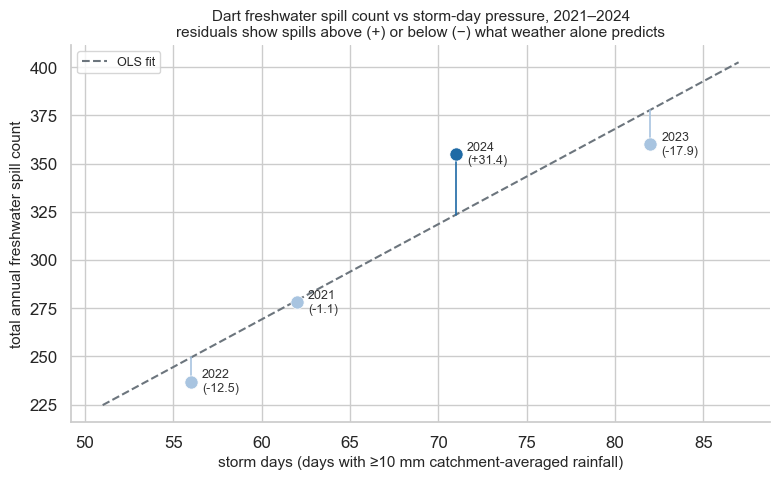

Saved: outputs/scale1_dart_ols_residuals.png


In [238]:
fig, ax = plt.subplots(figsize=(8, 5))# creates the figure and a single axes object to plot on - figsize sets the output dimensions

x_range = np.linspace(dart_annual['storm_days_10'].min() - 5, dart_annual['storm_days_10'].max() + 5, 200) # generates 200 evenly spaced x values slightly beyond the observed range so the fit line doesnt end too abruptly
y_fit = dart_ols_10.params['Intercept'] + dart_ols_10.params['storm_days_10'] * x_range # finds y = a + bx at each point in x_range using the fitted intercept and slope coefficients - gives the predicted spill count at any storm_days_10 value
ax.plot(x_range, y_fit, color=COLOUR_NATIONAL, linewidth=1.5, linestyle='--', label='OLS fit', zorder=2) # draws the fit line in grey - zorder=2 places it behind the data points and residual lines (which are drawn at higher zorders)

for _, row in dart_annual.iterrows(): # iterates through dart_annual row by row - one iteration per year - giving access to each years storm days, fitted value, actual count and residual as a named series
    above = row['residual_10'] > 0 # true if actual spill count is above the models prediction for this year - determines colour and sign prefix below
    colour = COLOUR_DART if above else '#a8c4e0' # dark blue if above predicted, light blue if below - makes the direction of each residual visible without needing to read the label
    residual_sign = '+' if above else '' # adds a + before positive residuals so labels read (+31.4) and (-17.9) rather than (31.4) and (-17.9)

    # plots a vertical line between the fitted value and the actual value for this year - the length of this line is the residual, its direction shows whether actual was above or below the models ptrediction
    ax.plot([row['storm_days_10'], row['storm_days_10']], [row['fitted_10'], row['total_spill_count']],
            color=colour, linewidth=1.2, zorder=3)

    ax.scatter(row['storm_days_10'], row['total_spill_count'],
               color=colour, s=90, zorder=5, edgecolors='white', linewidths=0.5) # plots the actual observed spill count - zorder=5 ensures it draws on top of the residual line

    ax.annotate(f"{int(row['year'])}\n({residual_sign}{row['residual_10']:.1f})",
                xy=(row['storm_days_10'], row['total_spill_count']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color='#333333', va='center') # places a text label at each point showing the year and residual value - xytext=(8,0) offsets it to the right so it doesnt overlap the marker

# defines the labels and styling
ax.set_xlabel('storm days (days with ≥10 mm catchment-averaged rainfall)', fontsize=11)
ax.set_ylabel('total annual freshwater spill count', fontsize=11)
ax.set_title('Dart freshwater spill count vs storm-day pressure, 2021–2024\nresiduals show spills above (+) or below (−) what weather alone predicts', fontsize=11)
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'scale1_dart_ols_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/scale1_dart_ols_residuals.png') # prints save location and filename

### Section 4c - Sensitivity Check: Storm Day Threshold
Scale 1 analysis - re-runs the OLS model using storm_days_15 and storm_days_20 thresholds to confirm that the primary findings are robust to the choice of 10mm as the storm day cutoff.
> here: the choice of 10mm as the storm day threshold is a methodological judgement - this cell tests sensitivity to that choice by re-running the same OLS substituting storm_days_15 and storm_days_20 as the regressor>the three thresholds span a natural progression from moderately heavy rainfall (10mm) through heavy (15mm) to very heavy (20mm) - chosen to bracket the plausible range of what constitutes a meaningful storm event for combined sewer overflow activation>stores fitted values and residuals for each threshold>prints a comparison table of model fit and year by year residuals>with only 4 observations highly correlated regressors will produce similar r-squared values - the meaningful test is whether residual signs and rankings are consistent across thresholds

---
<!-- HACKMD NARRATIVE - REMOVE BEFORE SUBMISSION
here: short paragraph - the 10mm threshold is a judgement call, so we test whether the findings hold at higher cutoffs too>at 10mm and 15mm, 2024 retains its positive residual and the pattern holds>at 20mm the picture shifts - with only four years of data, pushing the threshold this high leaves the model sensitive to how individual extreme rainfall days happen to fall across years>the core finding is robust at the thresholds most relevant to combined sewer overflow activation, where moderate and heavy rainfall days are what matter
-->
---

In [243]:
# fits OLS at 15mm and 20mm thresholds - mirrors the structure of dart_ols_10 in section 4a
dart_ols_15 = smf.ols('total_spill_count ~ storm_days_15', data=dart_annual).fit() # same model as dart_ols_10 but with storm_days_15 as regressor
dart_ols_20 = smf.ols('total_spill_count ~ storm_days_20', data=dart_annual).fit() # same model again with storm_days_20 as regressor

# stores fitted values and residuals for each threshold - positive residual means more spills than the model predicted
dart_annual['fitted_15'] = dart_ols_15.fittedvalues
dart_annual['residual_15'] = dart_ols_15.resid
dart_annual['fitted_20'] = dart_ols_20.fittedvalues
dart_annual['residual_20'] = dart_ols_20.resid

# prints the model summary statistics across all three thresholds side by side
print('Scale 1 OLS sensitivity check - threshold comparison:')
print(f"{'metric':<28} {'10mm':>8} {'15mm':>8} {'20mm':>8}")
print('-' * 56)
print(f"{'R-squared':<28} {dart_ols_10.rsquared:>8.3f} {dart_ols_15.rsquared:>8.3f} {dart_ols_20.rsquared:>8.3f}")
print(f"{'adj. R-squared':<28} {dart_ols_10.rsquared_adj:>8.3f} {dart_ols_15.rsquared_adj:>8.3f} {dart_ols_20.rsquared_adj:>8.3f}")
print(f"{'coefficient (spills/storm day)':<28} {dart_ols_10.params[1]:>8.3f} {dart_ols_15.params[1]:>8.3f} {dart_ols_20.params[1]:>8.3f}") # params[1] is the slope coefficient in each single regressor model

# prints residuals by year across all three thresholds
print(f"{'year':<8} {'residual_10':>12} {'residual_15':>12} {'residual_20':>12}")
print('-' * 48)
for _, row in dart_annual.iterrows(): # one row per year
    print(f"{int(row['year']):<8} {row['residual_10']:>12.1f} {row['residual_15']:>12.1f} {row['residual_20']:>12.1f}")

Scale 1 OLS sensitivity check - threshold comparison:
metric                           10mm     15mm     20mm
--------------------------------------------------------
R-squared                       0.865    0.956    0.986
adj. R-squared                  0.797    0.933    0.979
coefficient (spills/storm day)    4.940    8.701    8.159
year      residual_10  residual_15  residual_20
------------------------------------------------
2021             -1.1          1.0          9.3
2022            -12.5         -5.2         -7.3
2023            -17.9        -12.8          1.5
2024             31.4         17.0         -3.5


> finding: r-squared rises with threshold (0.865 at 10mm, 0.956 at 15mm, 0.986 at 20mm) - with only 4 observations this reflects increasing correlation between the specific regressors and the outcome rather than a genuinely better specified model>adjusted r-squared says the same (0.797, 0.933, 0.979)>similar fit statistics across correlated regressors are expected (at this sample size) and arent in themselves the robustness test
> finding: at 10mm and 15mm, 2024 retains the largest positive residual (+31.4 and +17.0 respectively) - confirming the anomaly is not an artefact of the 10mm threshold choice at the rainfall levels most relevant to combined sewer overflow activation>at 20mm, 2024 flips to a small negative residual (-3.5) - at very high thresholds the model becomes sensitive to how individual extreme rainfall days fall across the four years, and the small sample means this shift should not be over stressed>the sensitivity check supports the 10mm and 15mm findings while honestly flagging the 20mm result>the more meaningful sensitivity check which will help to verify scale 1 after the fact will be the scale 2 sensitivity check>working with a larger sample, meaning greater statistical power to see differences between thresholds.